In [42]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [43]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.interpolate import RegularGridInterpolator
import seaborn as sns
from matplotlib.colors import ListedColormap

from mpl_toolkits.axes_grid1.inset_locator import mark_inset

from itertools import product
import matplotlib.colors as mcolors
import matplotlib.patches as patches

from wrf_io import postproc

In [44]:
fontsize = 24
plt.rcParams['xtick.labelsize'] = 20 
plt.rcParams['ytick.labelsize'] = 20 

plt.rcParams.update({
    'text.usetex': True,
    'text.latex.preamble': r'\usepackage{amsfonts}'
})

In [45]:
casenames = np.load('/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/sweep_names.npy')
U_loc   = np.load('/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/U_loc.npy')
dir_loc = np.load('/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/dir_loc.npy')
Uhub    = np.load('/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/Uhub.npy')
wrf_rel = np.load('/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/wrf_rel.npy')
wrf_vax = np.load('/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/wrf_vax.npy')
wrf_vtn = np.load('/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/wrf_vtn.npy')
wrf_cax = np.load('/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/wrf_cax.npy')
wrf_cot = np.load('/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/wrf_cot.npy')
wrf_ind = np.load('/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/wrf_ind.npy')
wrf_thr = np.load('/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/wrf_thr.npy')
wrf_pow = np.load('/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/wrf_pow.npy')
shapiro = np.load('/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/shapiro.npy')
wrf_tsr = np.load('/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/wrf_tsr.npy')
wrf_omg = np.load('/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/wrf_omg.npy')
Nelm    = np.load("/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/rotor_dims_10MW.npz")['Nelm']
Nsct    = np.load("/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/rotor_dims_10MW.npz")['Nsct']
rOverR  = np.load("/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/rotor_dims_10MW.npz")['rOverR']
R       = np.load("/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/rotor_dims_10MW.npz")['R']

In [46]:
x_temp = [0,1,2,3,4,5,6]
y_temp = [16,15,14,13,12,11,10,9,8,7,6,5,4,3,2,1,0]
coords = [pair for pair in product(x_temp, y_temp)]

In [47]:
# Define the specific equation (e.g., linear: y = a * x + b)
def madsen_func(CT, a, b, c):

    return a * CT**3 + b * CT**2 + c * CT

In [48]:
veer  = np.array([-80,-70,-60,-50,-40,-30,-20,-10,0,10,20,30,40,50,60,70,80])
shear = np.array([-6,-4,-2,0,2,4,6])

training = [pair for pair in product(shear, veer)]

indices_80 = [i for i, (s, v) in enumerate(training) if abs(v) == 80 ]
indices_70 = [i for i, (s, v) in enumerate(training) if abs(v) == 70 ]
indices_60 = [i for i, (s, v) in enumerate(training) if abs(v) == 60 ]
indices_50 = [i for i, (s, v) in enumerate(training) if abs(v) == 50 ]
indices_40 = [i for i, (s, v) in enumerate(training) if abs(v) == 40 ]
indices_30 = [i for i, (s, v) in enumerate(training) if abs(v) == 30 ]
indices_20 = [i for i, (s, v) in enumerate(training) if abs(v) == 20 ]
indices_10 = [i for i, (s, v) in enumerate(training) if abs(v) == 10 ]
indices_00 = [i for i, (s, v) in enumerate(training) if abs(v) == 0 ]

In [49]:
a_coeffs = np.zeros((len(veer),len(shear)))
b_coeffs = np.zeros((len(veer),len(shear)))
c_coeffs = np.zeros((len(veer),len(shear)))

wrf_pow_mat = np.zeros((len(veer),len(shear)))
wrf_thr_mat = np.zeros((len(veer),len(shear)))
wrf_ind_mat = np.zeros((len(veer),len(shear)))
wrf_cot_mat = np.zeros((len(veer),len(shear)))

In [50]:
a_mom_origin = np.linspace(0,0.015,5)
ct_mom_origin = 4 * a_mom_origin * (1 - a_mom_origin)
# a_mom_origin = 0
# ct_mom_origin = 0

In [51]:
for i in range(len(casenames)):
# for i in [59]:
    wrf_pow_mat[coords[i][1],coords[i][0]] = wrf_pow[i]
    wrf_thr_mat[coords[i][1],coords[i][0]] = wrf_thr[i]
    wrf_ind_mat[coords[i][1],coords[i][0]] = wrf_ind[i]
    wrf_cot_mat[coords[i][1],coords[i][0]] = wrf_cot[i]

    a_mom = np.append(a_mom_origin, wrf_ind[i])
    ct_mom = np.append(ct_mom_origin, wrf_cot[i])

    params, covariance = curve_fit(madsen_func, ct_mom, a_mom)

    a_fit, b_fit, c_fit = params

    a_coeffs[coords[i][1],coords[i][0]] = a_fit
    b_coeffs[coords[i][1],coords[i][0]] = b_fit
    c_coeffs[coords[i][1],coords[i][0]] = c_fit

np.save('/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/a_coeffs.npy',   a_coeffs)
np.save('/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/b_coeffs.npy',   b_coeffs)
np.save('/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/c_coeffs.npy',   c_coeffs)



In [52]:
wrf_ref_index      = [i for i, (s, v) in enumerate(training) if (v == 0 and s == 0)]

wrf_power_dev     = postproc.per_error(wrf_pow_mat, wrf_pow[wrf_ref_index])
wrf_thrust_dev    = postproc.per_error(wrf_thr_mat, wrf_thr[wrf_ref_index])
wrf_induction_dev = postproc.per_error(wrf_ind_mat, wrf_ind[wrf_ref_index])

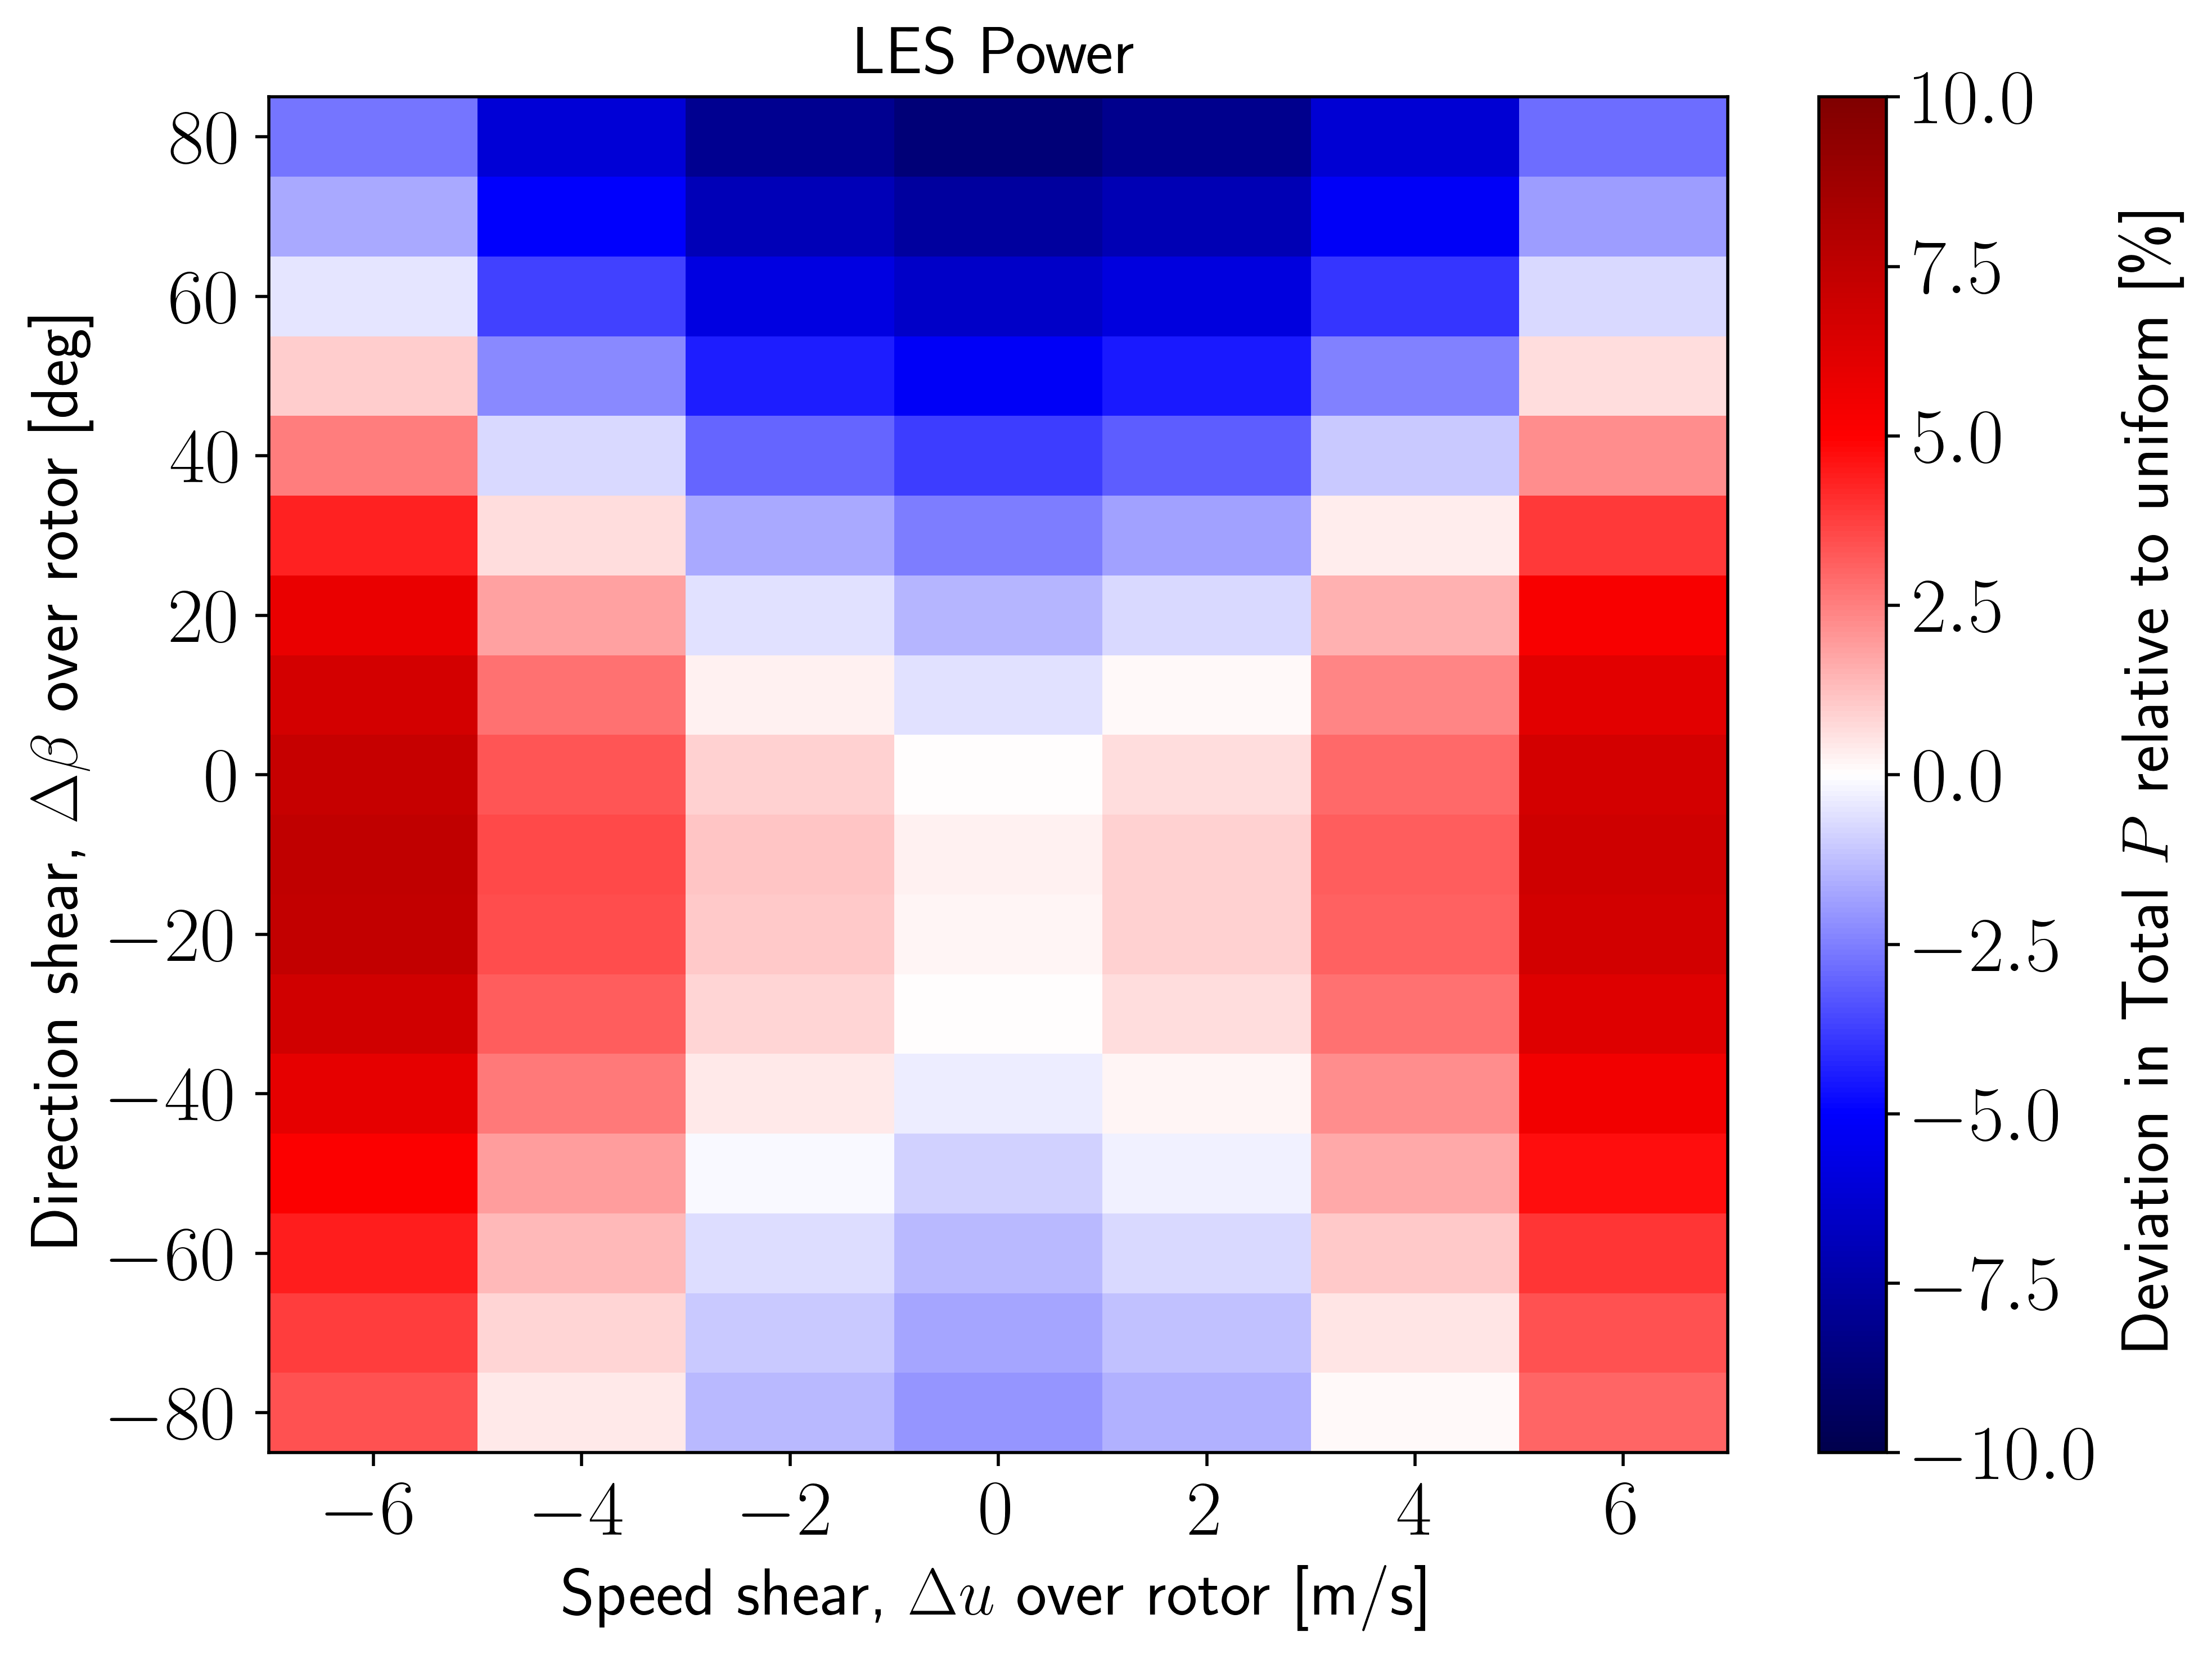

In [53]:
plt.figure(figsize=(8, 6))
contour = plt.pcolormesh(shear, veer[::-1], wrf_power_dev, cmap='seismic',vmin=-10,vmax=10)  # or use plt.contour
cbar = plt.colorbar(contour)
cbar.set_label(r'Deviation in Total $P$ relative to uniform [\%]', fontsize=17)

plt.xticks(shear)  # every second x tick
plt.yticks(veer[::-1][::2])  # every second y tick

# Labels and formatting
plt.xlabel('Speed shear, $\Delta u$ over rotor [m/s]', fontsize=17)
plt.ylabel('Direction shear, $\Delta \\beta$ over rotor [deg]', fontsize=17)
plt.title('LES Power', fontsize=17)
plt.tight_layout()
plt.show()

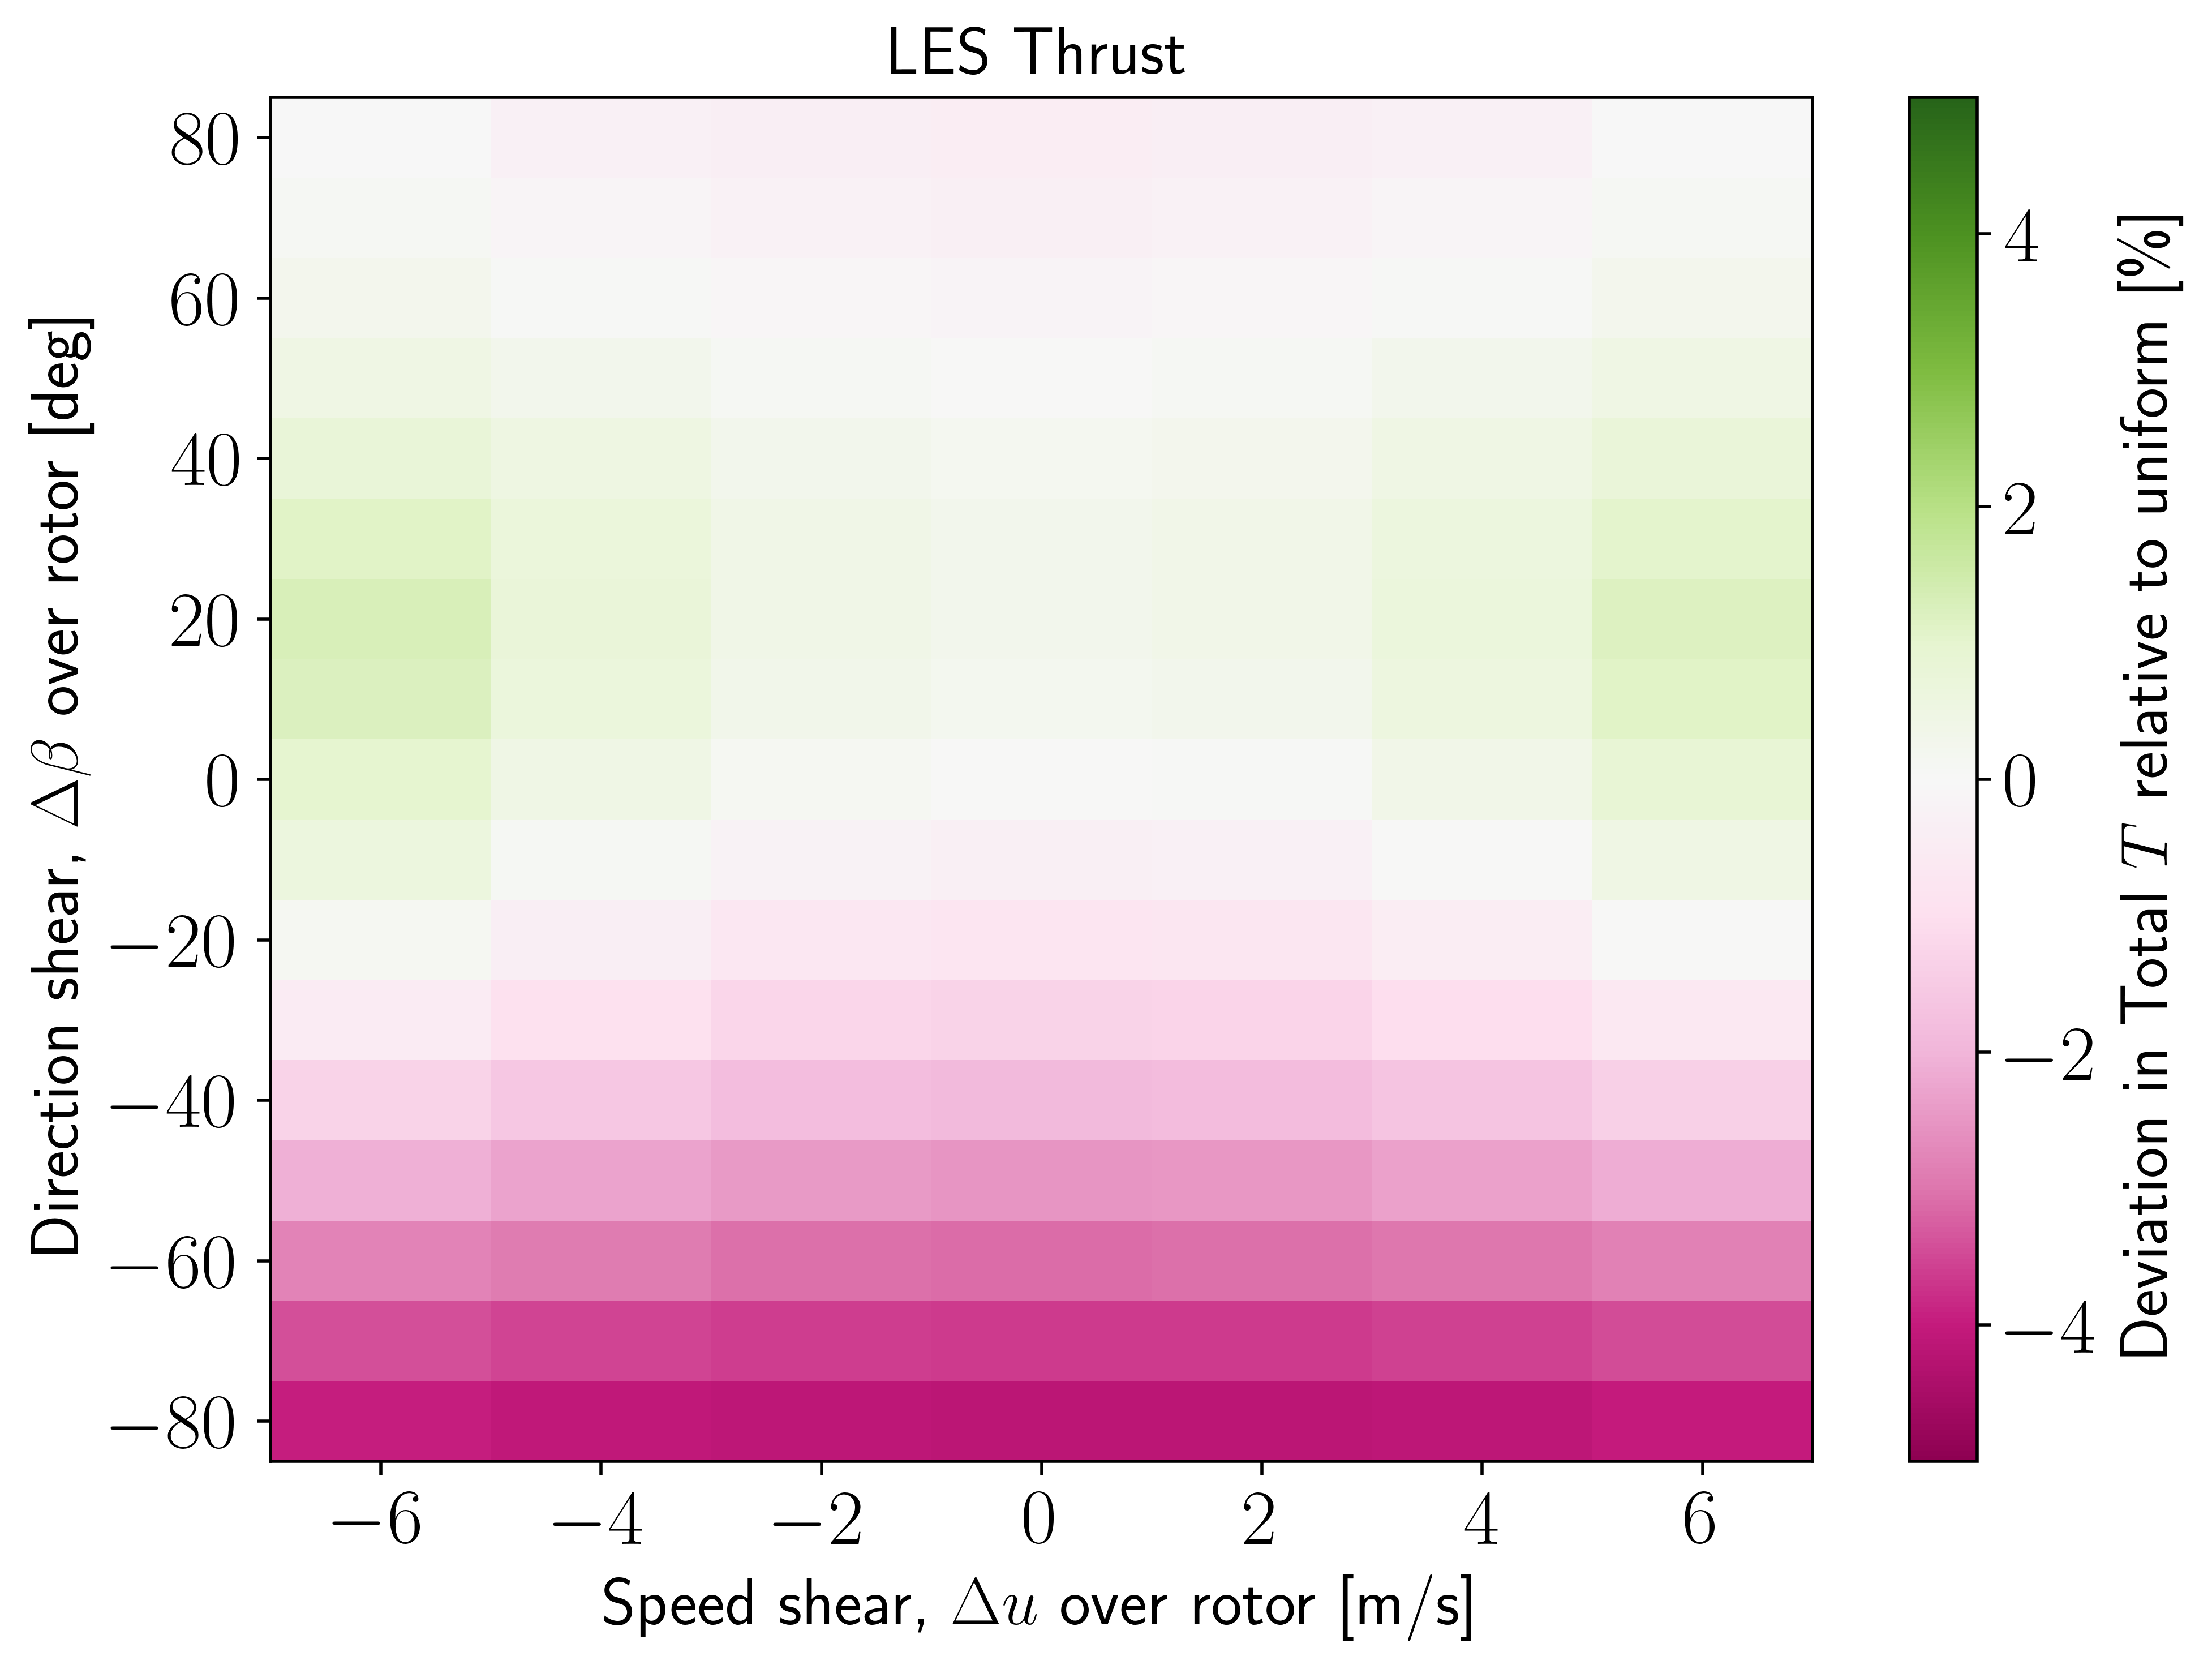

In [54]:
plt.figure(figsize=(8, 6))
contour = plt.pcolormesh(shear, veer[::-1], wrf_thrust_dev, cmap='PiYG',vmin=-5,vmax=5)  # or use plt.contour
cbar = plt.colorbar(contour)
cbar.set_label(r'Deviation in Total $T$ relative to uniform [\%]', fontsize=17)

plt.xticks(shear)  # every second x tick
plt.yticks(veer[::-1][::2])  # every second y tick

# Labels and formatting
plt.xlabel('Speed shear, $\Delta u$ over rotor [m/s]', fontsize=17)
plt.ylabel('Direction shear, $\Delta \\beta$ over rotor [deg]', fontsize=17)
plt.title('LES Thrust', fontsize=17)
plt.tight_layout()
plt.show()

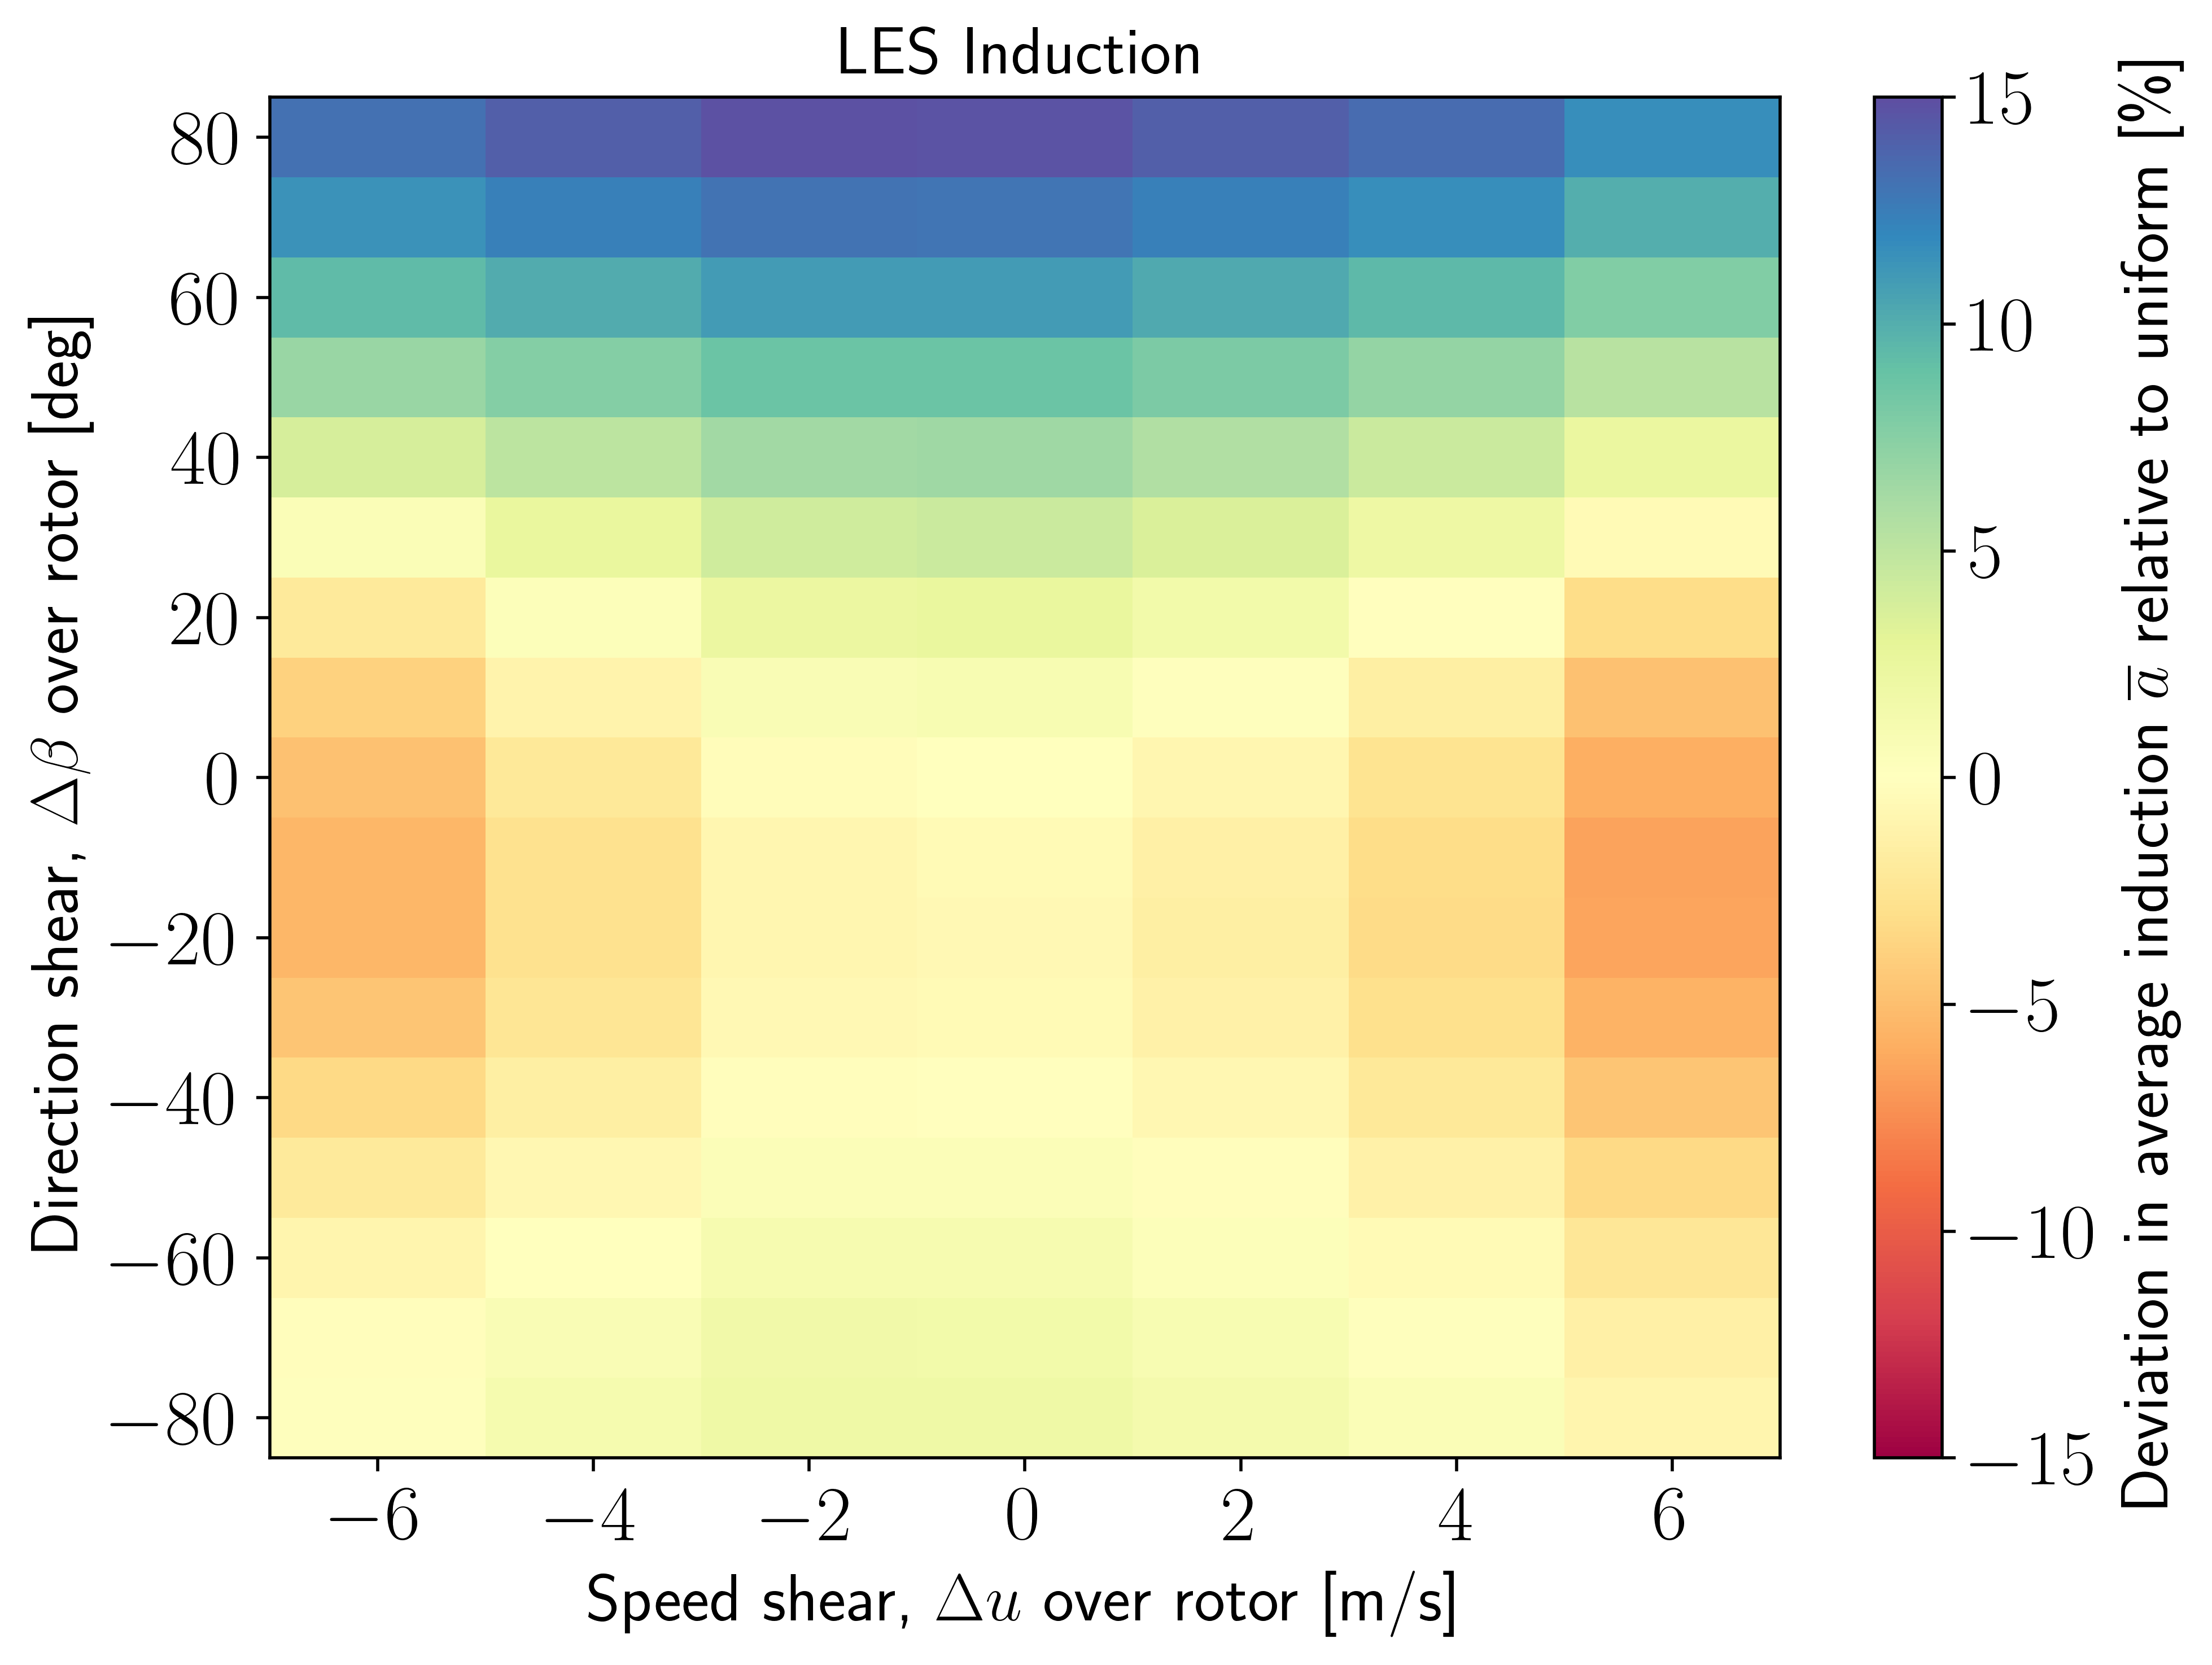

In [55]:
plt.figure(figsize=(8, 6))
contour = plt.pcolormesh(shear, veer[::-1], wrf_induction_dev, cmap='Spectral',vmin=-15,vmax=15)  # or use plt.contour
cbar = plt.colorbar(contour)
cbar.set_label(r'Deviation in average induction $\overline{a}$ relative to uniform [\%]', fontsize=17)


plt.xticks(shear)  # every second x tick
plt.yticks(veer[::-1][::2])  # every second y tick

# Labels and formatting
plt.xlabel('Speed shear, $\Delta u$ over rotor [m/s]', fontsize=17)
plt.ylabel('Direction shear, $\Delta \\beta$ over rotor [deg]', fontsize=17)
plt.title('LES Induction', fontsize=17)
plt.tight_layout()
plt.show()

In [56]:
from MITRotor import BEM, BEMGeometry, IEA10MW, NoTipLoss, KraghAerodynamics, NoTangentialInduction, Madsen_Rotor_Momentum_AllV_AllS

In [57]:
rotor = IEA10MW()

mit_ind = np.zeros_like(wrf_pow, dtype='float')
mit_cot = np.zeros_like(wrf_pow, dtype='float')
mit_thr = np.zeros_like(wrf_pow, dtype='float')
mit_cop = np.zeros_like(wrf_pow, dtype='float')
mit_pow = np.zeros_like(wrf_pow, dtype='float')
iters   = np.zeros_like(wrf_pow, dtype='float')

mit_w   = np.zeros_like(wrf_pow, dtype='float')
mit_cax = np.zeros_like(wrf_pow, dtype='float')
mit_vax = np.zeros_like(wrf_pow, dtype='float')
mit_vtn = np.zeros_like(wrf_pow, dtype='float')

for count in range(len(mit_ind)):

    location = (coords[count][1],coords[count][0])

    bem = BEM(rotor=rotor, geometry=BEMGeometry(Nr=26,Ntheta=158), aerodynamic_model=KraghAerodynamics(), tiploss_model=NoTipLoss(), momentum_model=Madsen_Rotor_Momentum_AllV_AllS(veer=location), tangential_induction_model=NoTangentialInduction(),index=count)

    # tsr = wrf_tsr[count]
    tsr = wrf_tsr[count] * 99.15 / 99.5

    sol = bem(0, tsr, 0, U = U_loc[:,:,count], wdir=dir_loc[:,:,count],index=count)

    rho = 1.225

    r = rOverR * rotor.R

    dr = (rotor.R - rotor.hub_radius)/Nelm

    dtheta = 2 * np.pi / Nsct

    chord = np.array([4.649046,4.844576,5.216862,5.647547,5.931514,5.96353,5.812206,5.569981,5.273268,4.94348,4.598646,4.251929,3.911027,3.581805,3.269938,2.978544,2.70897,2.462014,2.237137,2.035348,1.855479,1.691271,1.526768,1.308778,0.7955106,0.5734])
    rho = 1.225

    Vrel = np.sqrt((sol.Vax('sector'))**2 + sol.Vtan('sector')**2) * Uhub[count]
    L = 1/2 * rho * chord * (sol.Cl('sector') * Vrel**2).T
    D = 1/2 * rho * chord * (sol.Cd('sector') * Vrel**2).T
    phi = sol.phi('sector')

    FT = L.T * np.sin(phi) - D.T * np.cos(phi)
    FN = L.T * np.cos(phi) + D.T * np.sin(phi)

    sigma = 3/Nsct

    T = FN * dr * sigma

    P = FT.T * r * dr * sigma * wrf_omg[count] * 2 * np.pi / 60

    T_total = np.sum(T)/1e3
    P_total = np.sum(P)/1e6

    mit_cot[count] = sol.Ct()
    mit_thr[count] = T_total
    mit_pow[count] = P_total
    mit_cop[count] = sol.Cp()
    mit_ind[count] = sol.a()
    iters[count]   = sol.niter
    mit_w[count]   = sol.W()
    mit_cax[count] = sol.Cx()
    mit_vax[count] = sol.Vax()
    mit_vtn[count] = sol.Vtan()
    
iters

array([28., 28., 27., 27., 26., 25., 25., 25., 25., 26., 27., 29., 32.,
       34., 37., 40., 42., 29., 29., 28., 28., 27., 27., 26., 26., 27.,
       28., 29., 31., 33., 35., 38., 41., 44., 29., 29., 29., 29., 28.,
       28., 28., 28., 28., 29., 30., 32., 34., 37., 39., 42., 45., 29.,
       29., 29., 29., 28., 28., 28., 28., 28., 29., 30., 32., 34., 37.,
       39., 42., 45., 29., 29., 28., 28., 28., 27., 27., 27., 28., 28.,
       30., 31., 33., 36., 38., 41., 44., 28., 28., 28., 27., 27., 26.,
       26., 26., 26., 27., 28., 30., 32., 35., 37., 40., 43., 27., 27.,
       26., 26., 25., 24., 24., 24., 24., 25., 26., 28., 30., 33., 35.,
       38., 40.])

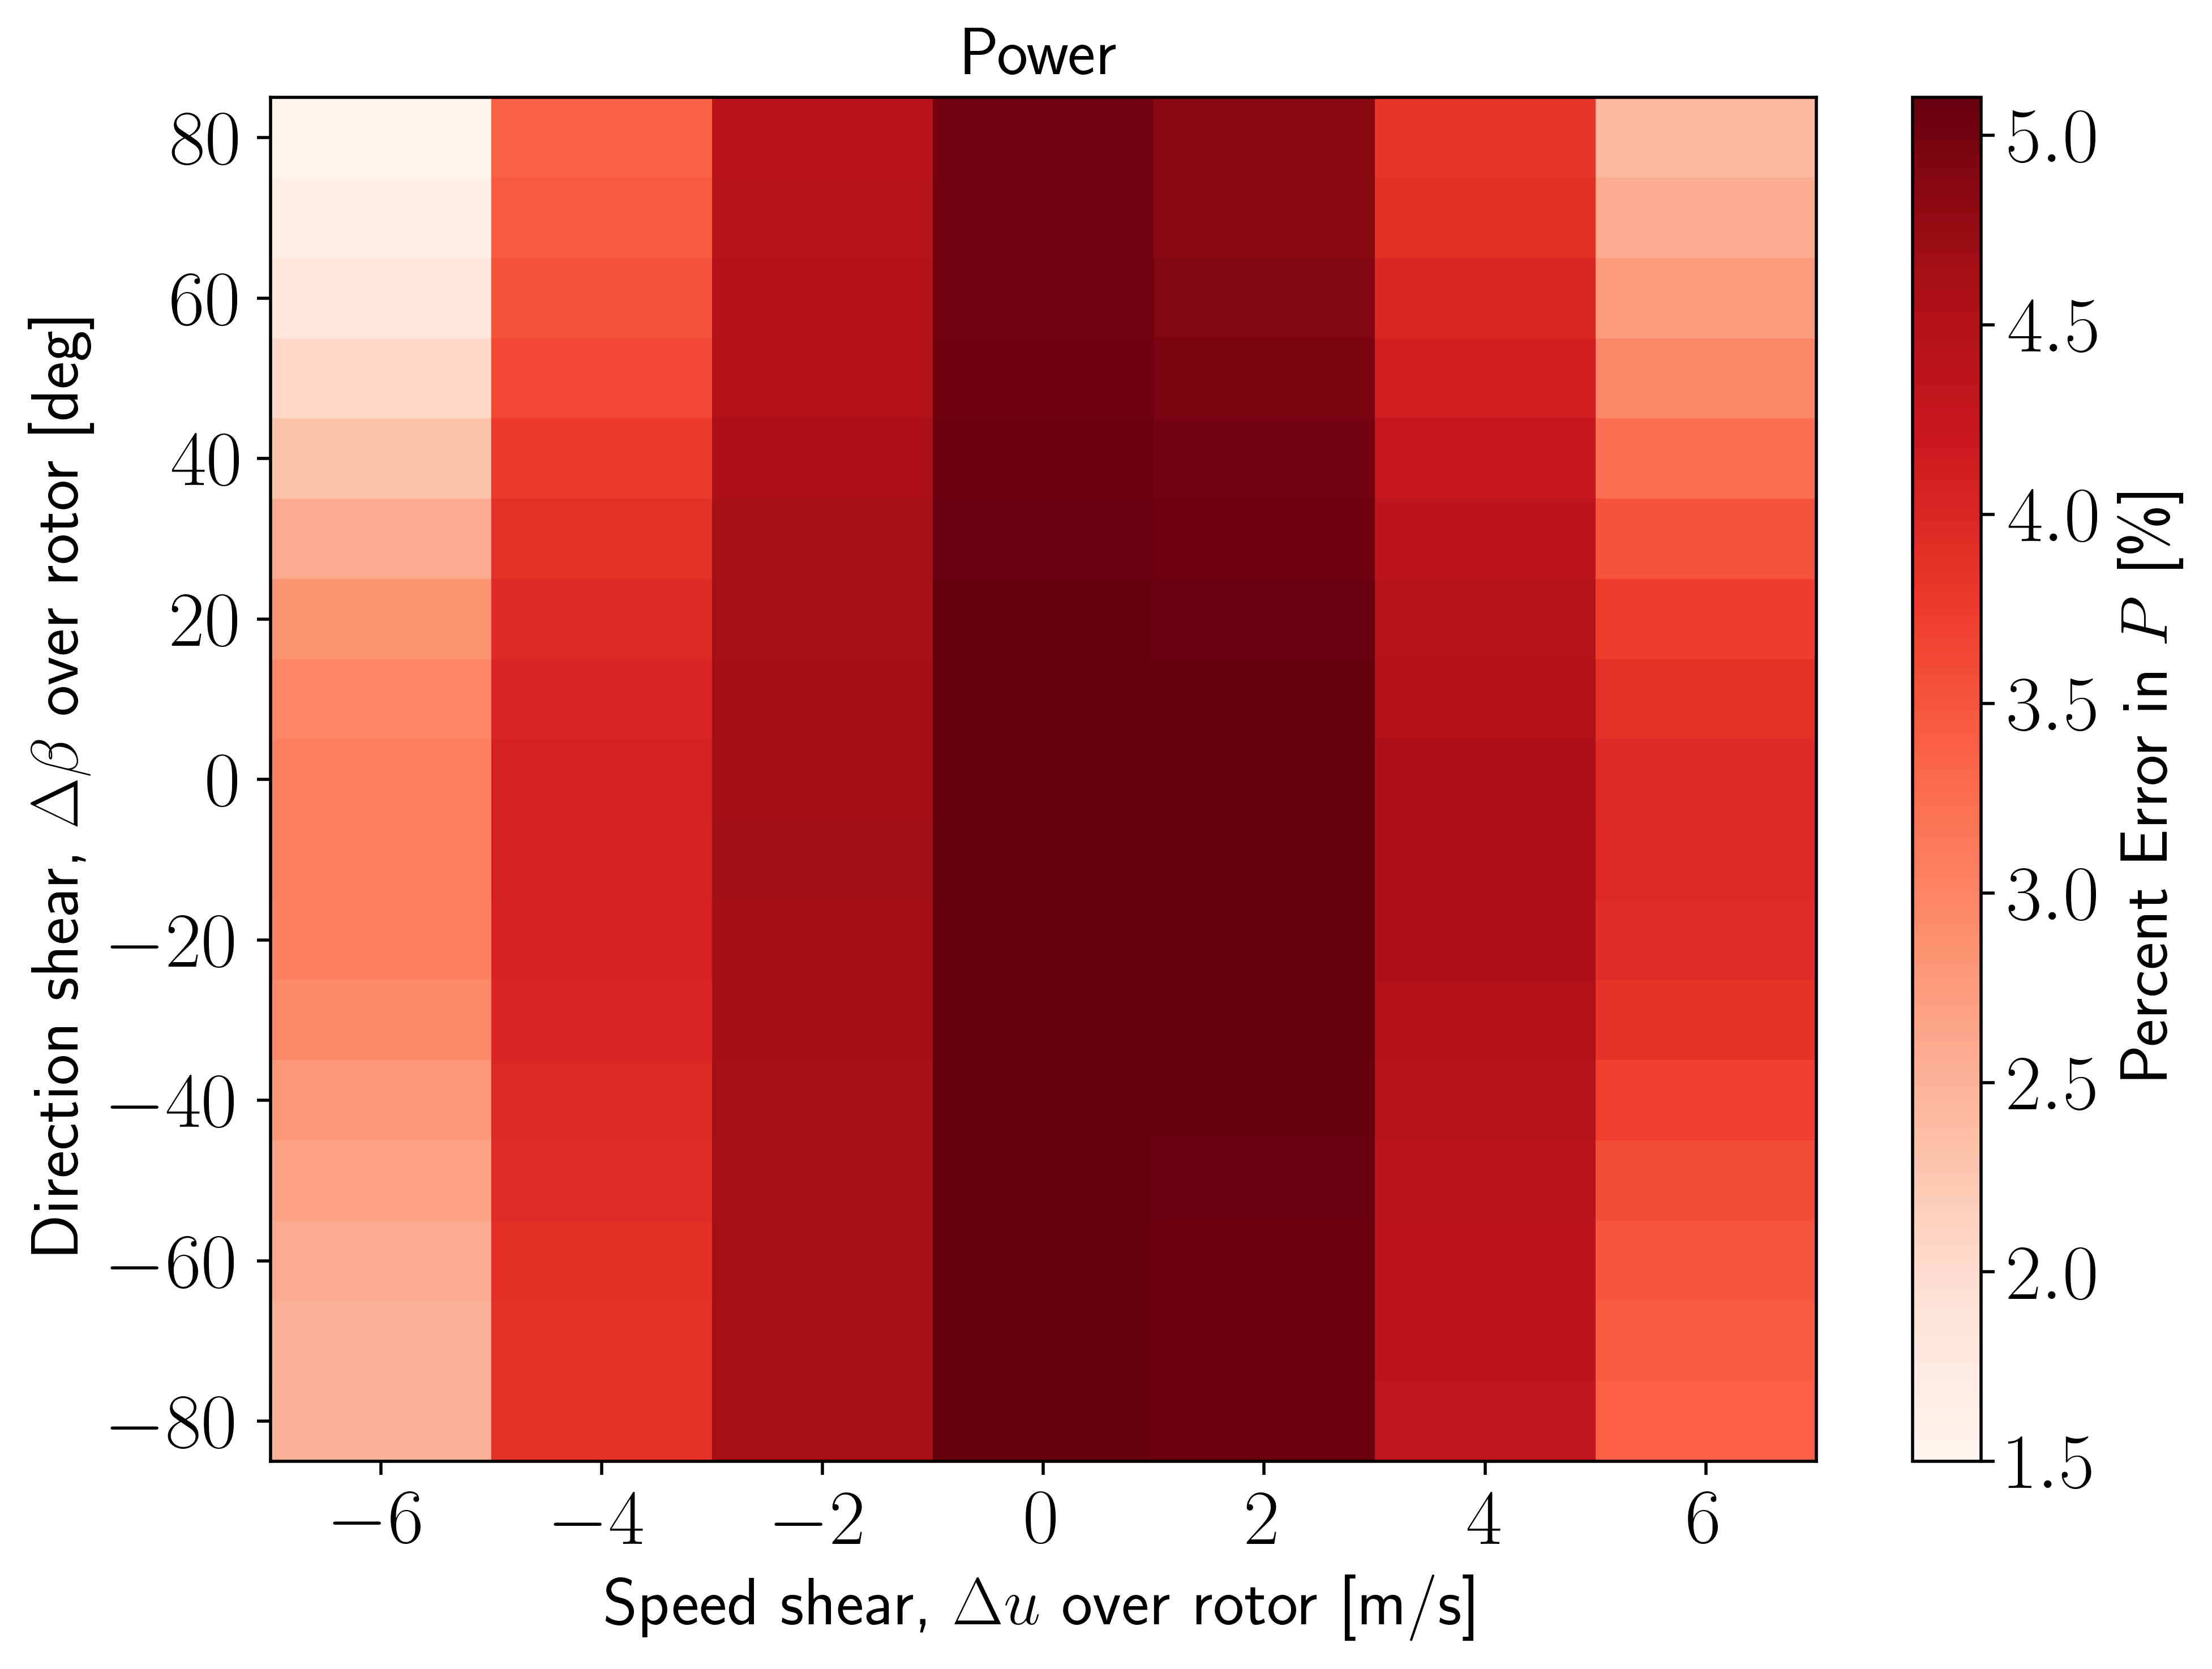

In [58]:
Z = np.zeros((len(veer),len(shear)))

# Create a seaborn color palette
reds_palette = sns.color_palette("Reds", as_cmap=True)  # List of RGB tuples

for count in range(len(coords)):

#     Z[coords[count][1],coords[count][0]] =  (mit_pow[count] - wrf_pow[count]/1e6)
    Z[coords[count][1],coords[count][0]] =  postproc.per_error(mit_pow[count], wrf_pow[count]/1e6)


plt.figure(figsize=(8, 6))
contour = plt.pcolormesh(shear, veer[::-1], Z, cmap=reds_palette,vmin=1.5,vmax=5.1)  # or use plt.contour
cbar = plt.colorbar(contour)
cbar.set_label(r'Percent Error in $P$ [\%]', fontsize=17)

plt.xticks(shear)  # every second x tick
plt.yticks(veer[::-1][::2])  # every second y tick

# Labels and formatting
plt.xlabel('Speed shear, $\Delta u$ over rotor [m/s]', fontsize=17)
plt.ylabel('Direction shear, $\Delta \\beta$ over rotor [deg]', fontsize=17)
plt.title('Power', fontsize=17)
plt.tight_layout()
plt.show()

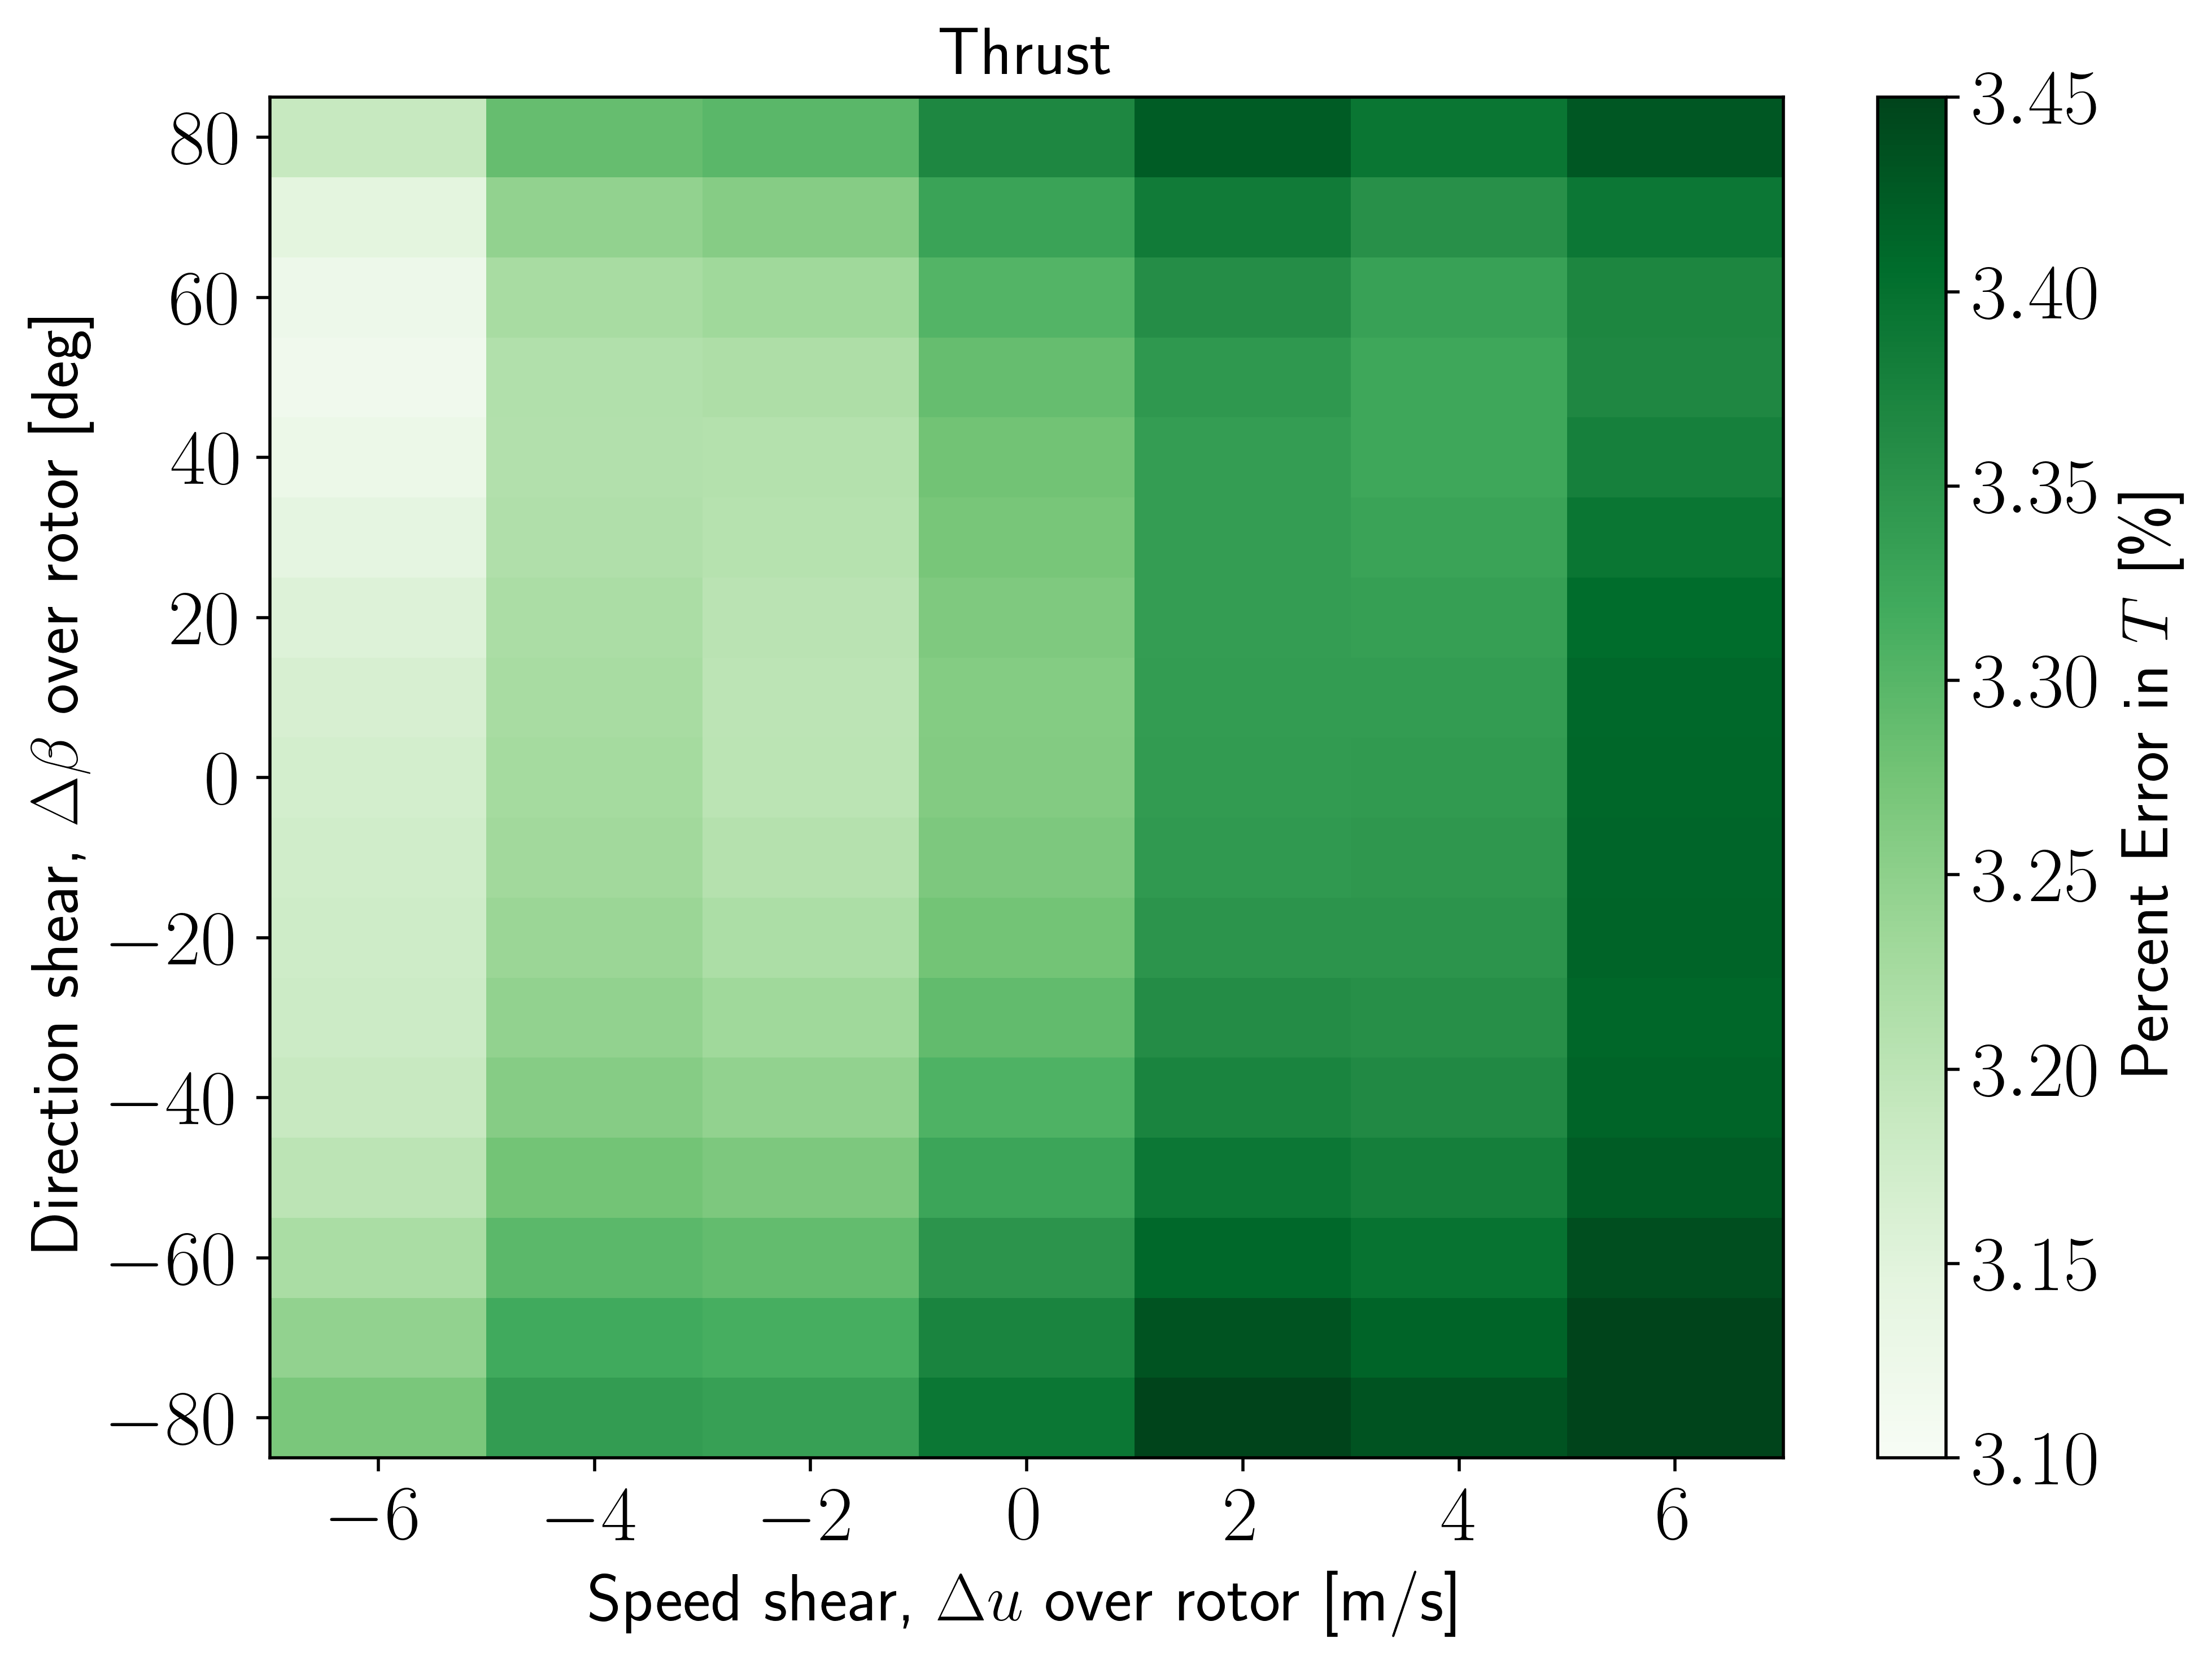

In [59]:
Z = np.zeros((len(veer),len(shear)))
# Create a seaborn color palette
greens_palette = sns.color_palette("Greens", as_cmap=True)  # List of RGB tuples

for count in range(len(coords)):

    # Z[coords[count][1],coords[count][0]] = (mit_thr[count] - wrf_thr[count]/1e3)
    Z[coords[count][1],coords[count][0]] =  postproc.per_error(mit_thr[count], wrf_thr[count]/1e3)

plt.figure(figsize=(8, 6))
contour = plt.pcolormesh(shear, veer[::-1], Z, cmap=greens_palette,vmin=3.1,vmax=3.45)  # or use plt.contour
cbar = plt.colorbar(contour)
cbar.set_label(r'Percent Error in $T$ [\%]', fontsize=17)

plt.xticks(shear)  # every second x tick
plt.yticks(veer[::-1][::2])  # every second y tick

# Labels and formatting
plt.xlabel('Speed shear, $\Delta u$ over rotor [m/s]', fontsize=17)
plt.ylabel('Direction shear, $\Delta \\beta$ over rotor [deg]', fontsize=17)
plt.title('Thrust', fontsize=17)
plt.tight_layout()
plt.show()

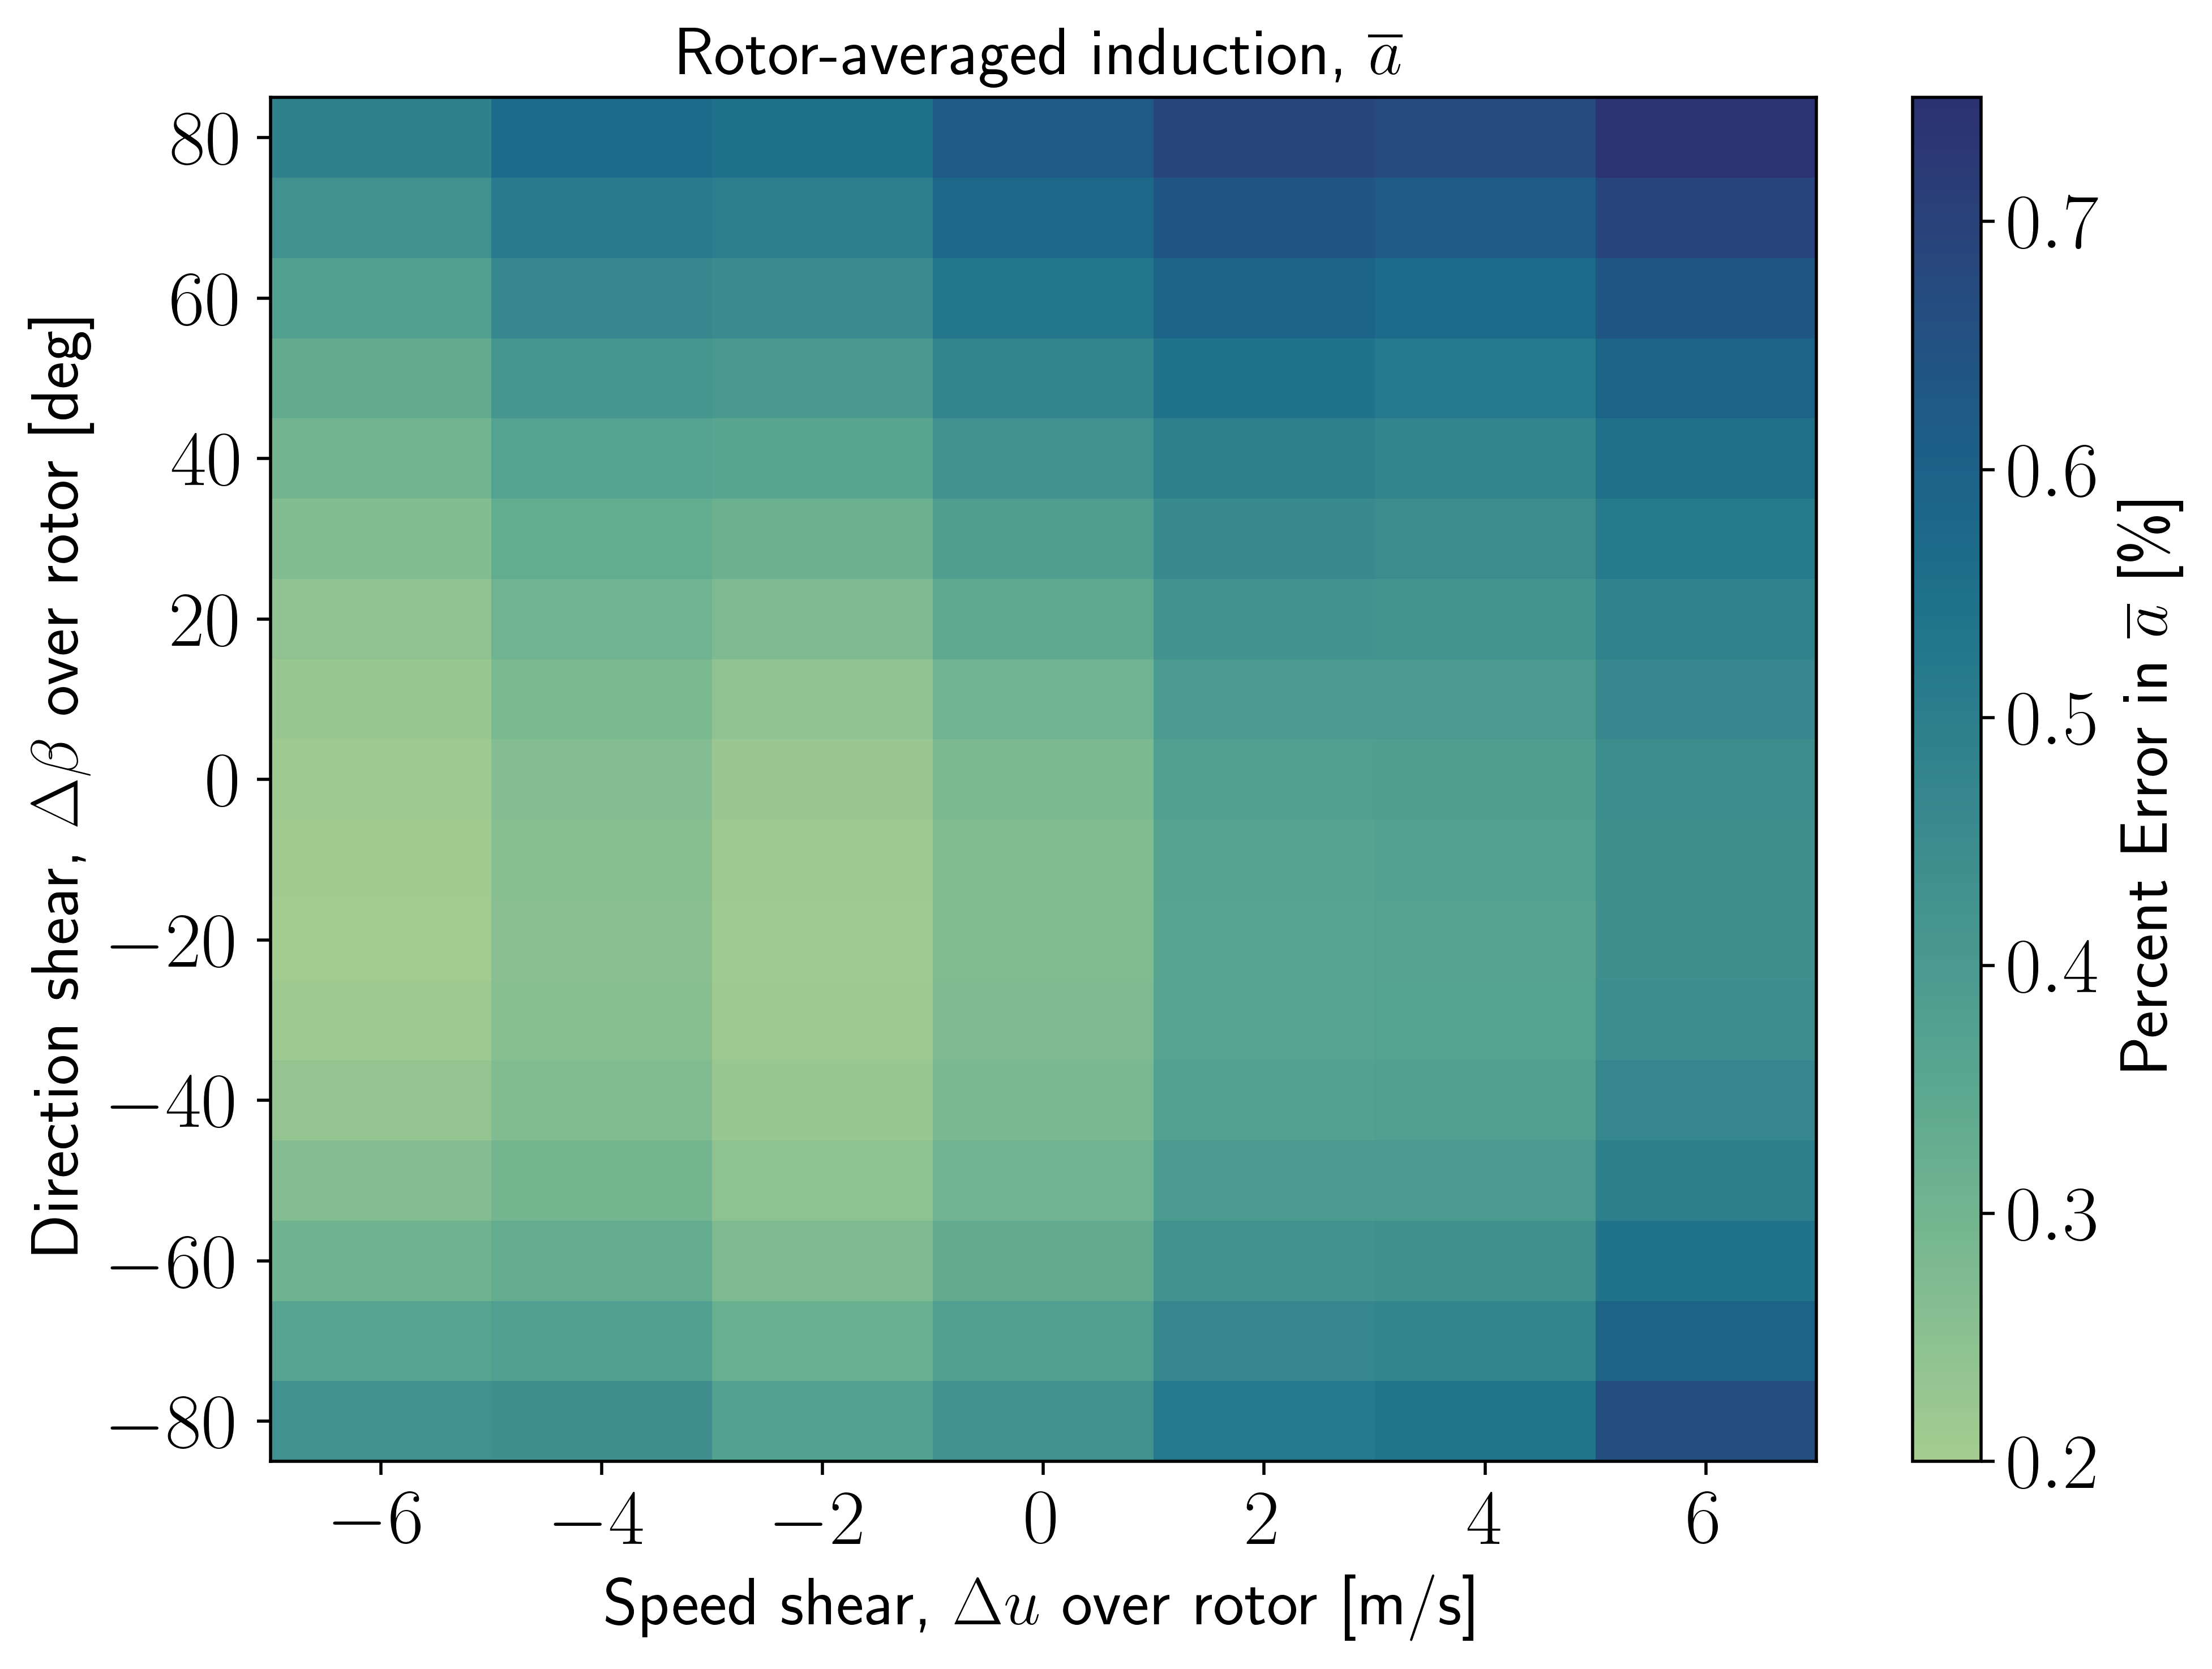

In [60]:
Z = np.zeros((len(veer),len(shear)))

ind_pallette = sns.color_palette("crest", as_cmap=True)

for count in range(len(coords)):

    # Z[coords[count][1],coords[count][0]] =  (mit_ind[count] - wrf_ind[count])
    Z[coords[count][1],coords[count][0]] =  postproc.per_error(mit_ind[count], wrf_ind[count])

plt.figure(figsize=(8, 6))
contour = plt.pcolormesh(shear, veer[::-1], Z, cmap=ind_pallette,vmin=0.2,vmax=0.75)  # or use plt.contour
cbar = plt.colorbar(contour)
cbar.set_label(r'Percent Error in $\overline{a}$ [\%]', fontsize=17)

plt.xticks(shear)  # every second x tick
plt.yticks(veer[::-1][::2])  # every second y tick

# Labels and formatting
plt.xlabel('Speed shear, $\Delta u$ over rotor [m/s]', fontsize=17)
plt.ylabel('Direction shear, $\Delta \\beta$ over rotor [deg]', fontsize=17)
plt.title('Rotor-averaged induction, $\overline{a}$', fontsize=17)
plt.tight_layout()
plt.show()

Text(0.5, 0, '$a$ [-]')

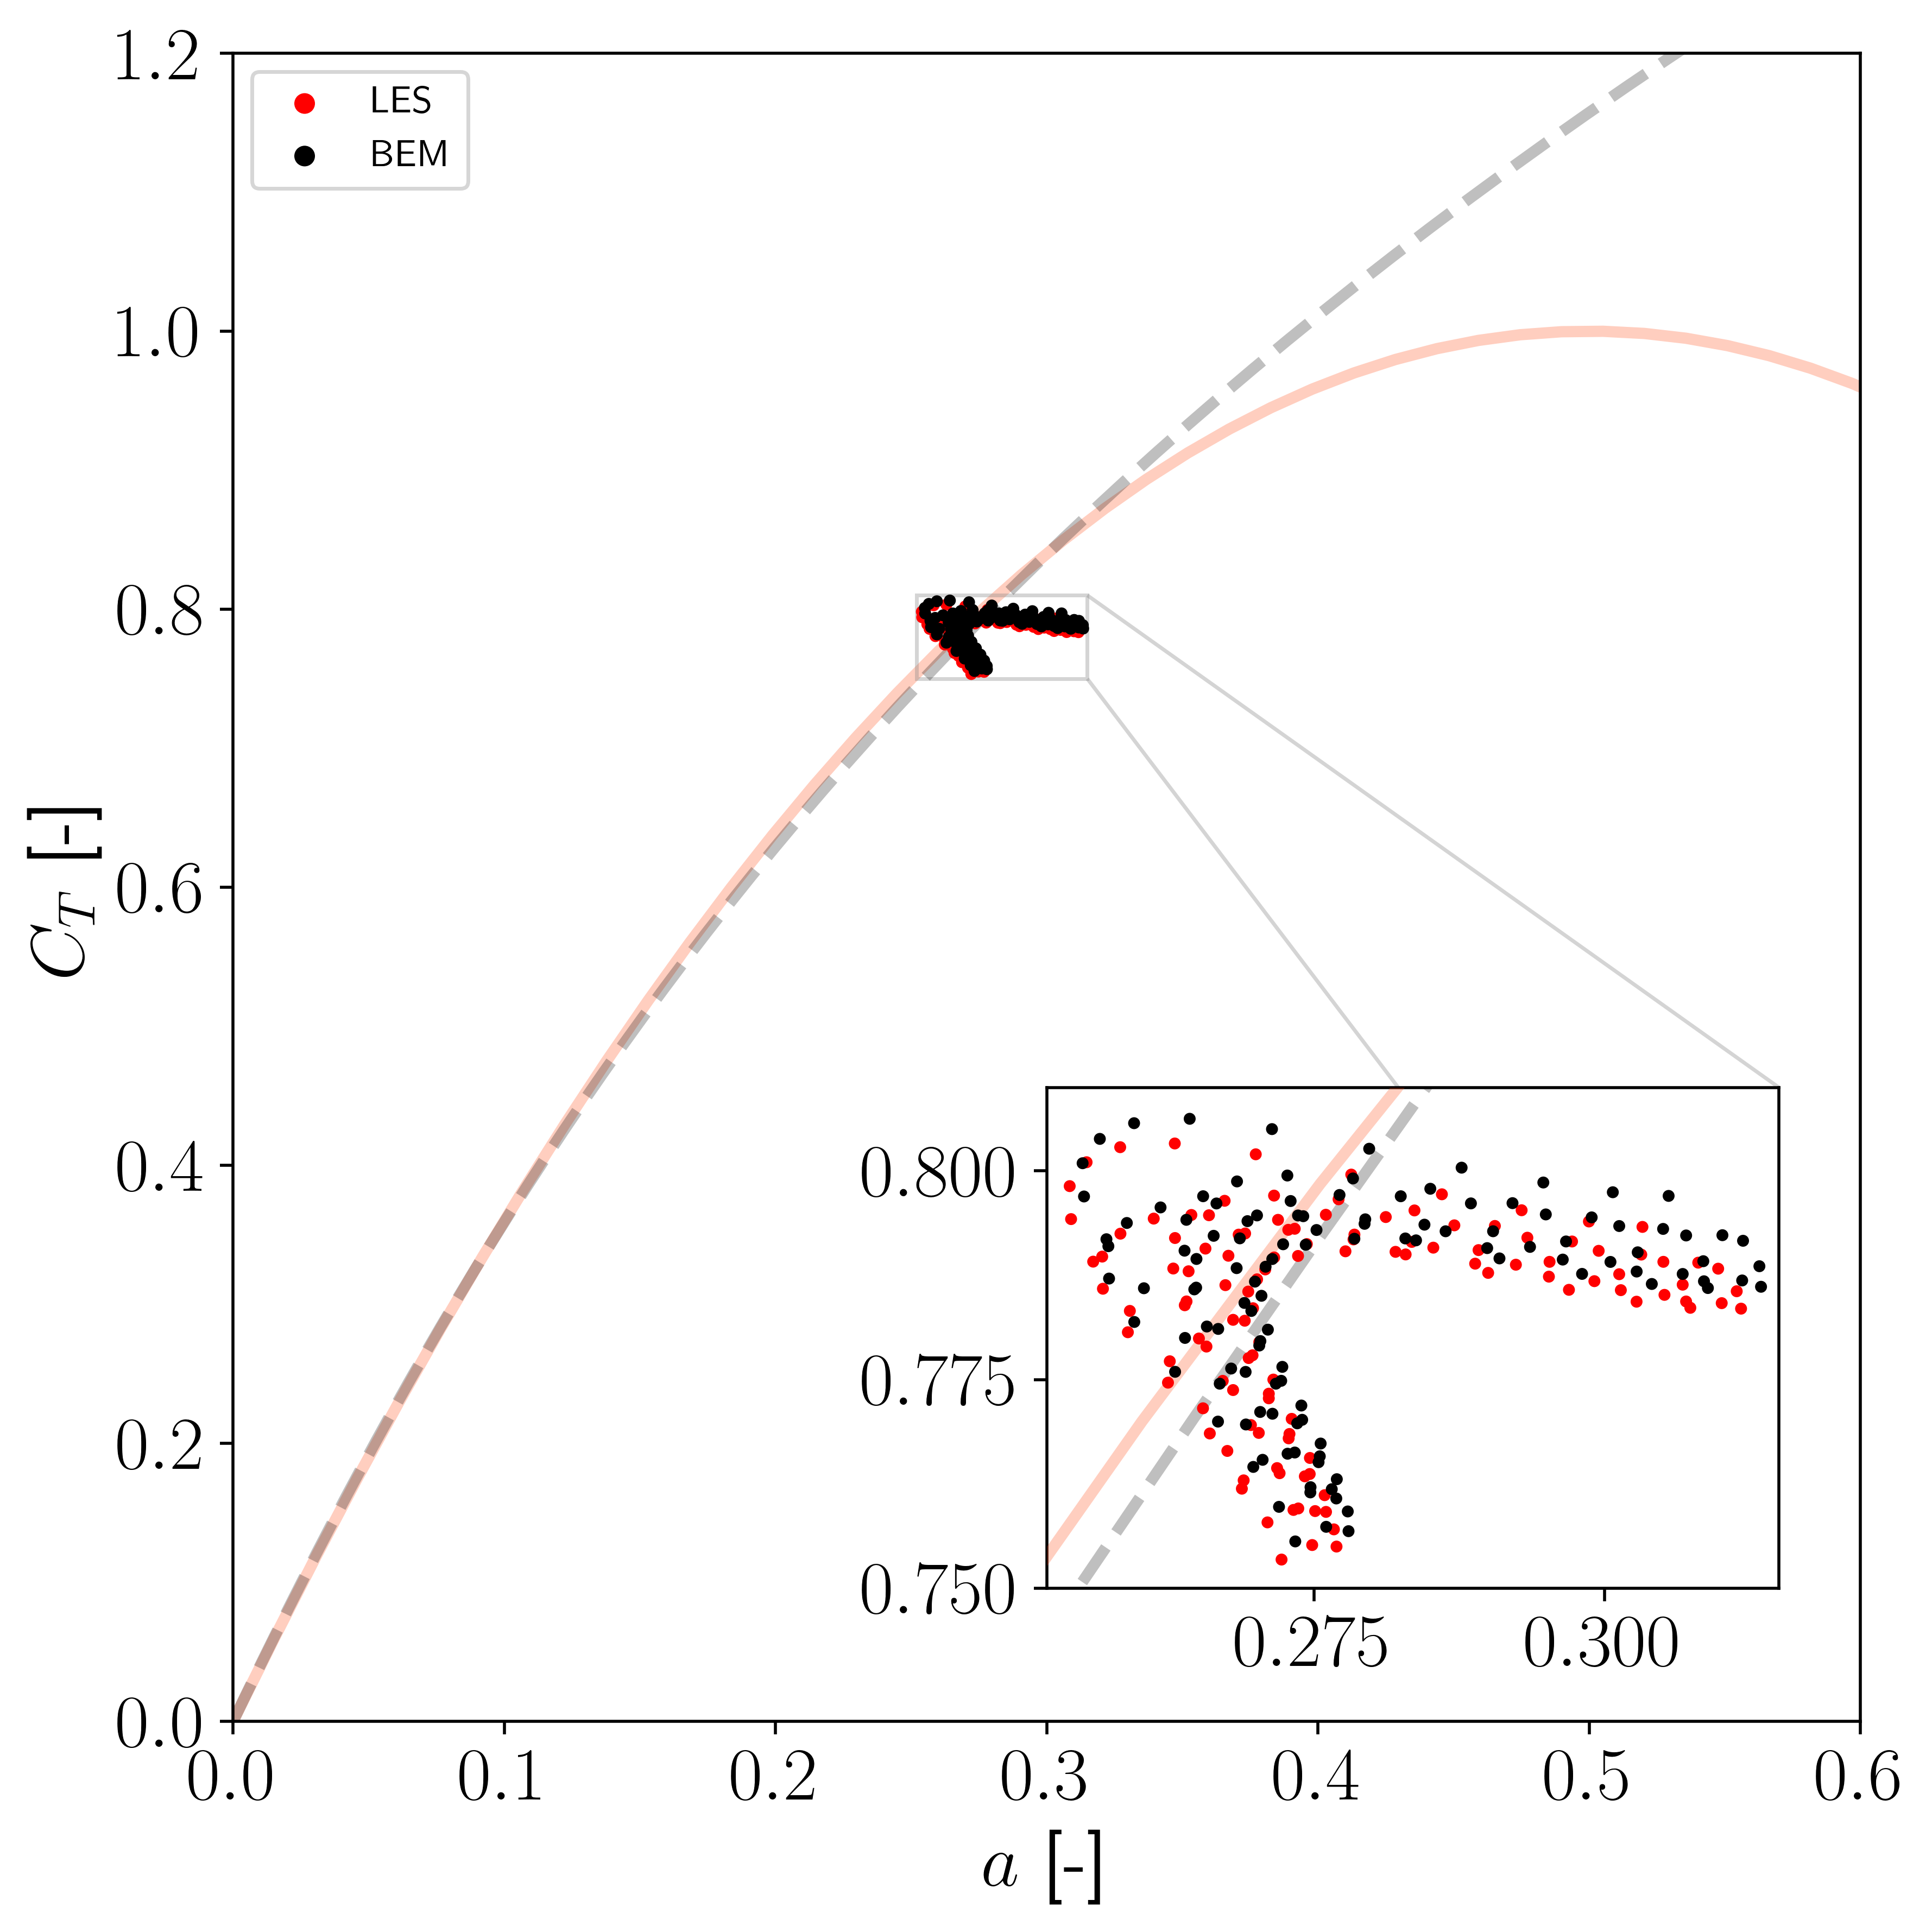

In [76]:
fig, ax = plt.subplots(figsize=(7, 7), constrained_layout=True,sharex=True, sharey=True)

a_mom  = np.linspace(0,0.75,50)
ct_mom = 4 * a_mom * (1 - a_mom)
ax.plot(a_mom, ct_mom, '#ff3c00',linewidth=3,zorder=1,alpha=0.25)

ct_mad = np.linspace(0,1.5,75)
k1 = 0.2460
k2 = 0.0586
k3 = 0.0883
a_mad = k3 * ct_mad**3 + k2 * ct_mad**2 + k1 * ct_mad
ax.plot(a_mad, ct_mad, 'k--',linewidth=3,zorder=2,alpha=0.25)

ax.scatter(wrf_ind, wrf_cot, s=10, edgecolor='none',color='r',zorder=3)

ax.scatter(mit_ind, mit_cot, s=10, edgecolor='none',color='k',zorder=3)

ax.scatter(-10, -10, s=30, edgecolor='none',color='r',zorder=3,label='LES')
ax.scatter(-10, -10, s=30, edgecolor='none',color='k',zorder=3,label='BEM')

ax.legend()

# === Add inset axes ===
# Example: Zoom into a cluster near a=0.32, CT=0.7

inset_ax = ax.inset_axes(
   [0.5, 0.08, 0.45, 0.3],  # [x, y, width, height] w.r.t. axes
    xlim=[0.252, 0.315], ylim=[0.75, 0.81] # sets viewport & tells relation to main axes
    # xticklabels=[], yticklabels=[]
)

# # Plot the same data inside the inset
inset_ax.plot(a_mom, ct_mom, '#ff3c00', linewidth=3, alpha=0.25,zorder=3)
inset_ax.plot(a_mad, ct_mad, 'k--', linewidth=3, alpha=0.25,zorder=3)

inset_ax.scatter(wrf_ind, wrf_cot, s=10, edgecolor='none',color='r',zorder=3)
inset_ax.scatter(mit_ind, mit_cot, s=10, edgecolor='none',color='k',zorder=3)

rect = patches.Rectangle((0.2, 0.6), 0.2, 0.3, facecolor='white', edgecolor='k',zorder=2)
inset_ax.add_patch(rect)

mark_inset(ax, inset_ax, loc1=1, loc2=4, fc="none", ec="0.5",zorder=1,alpha=1/3)


ax.set_xlim([0,0.6])
ax.set_ylim([0,1.2])

ax.set_ylabel('$C_T$ [-]', fontsize=20)
ax.set_xlabel('$a$ [-]', fontsize=20)

Text(0.5, 0, '$a$ [-]')

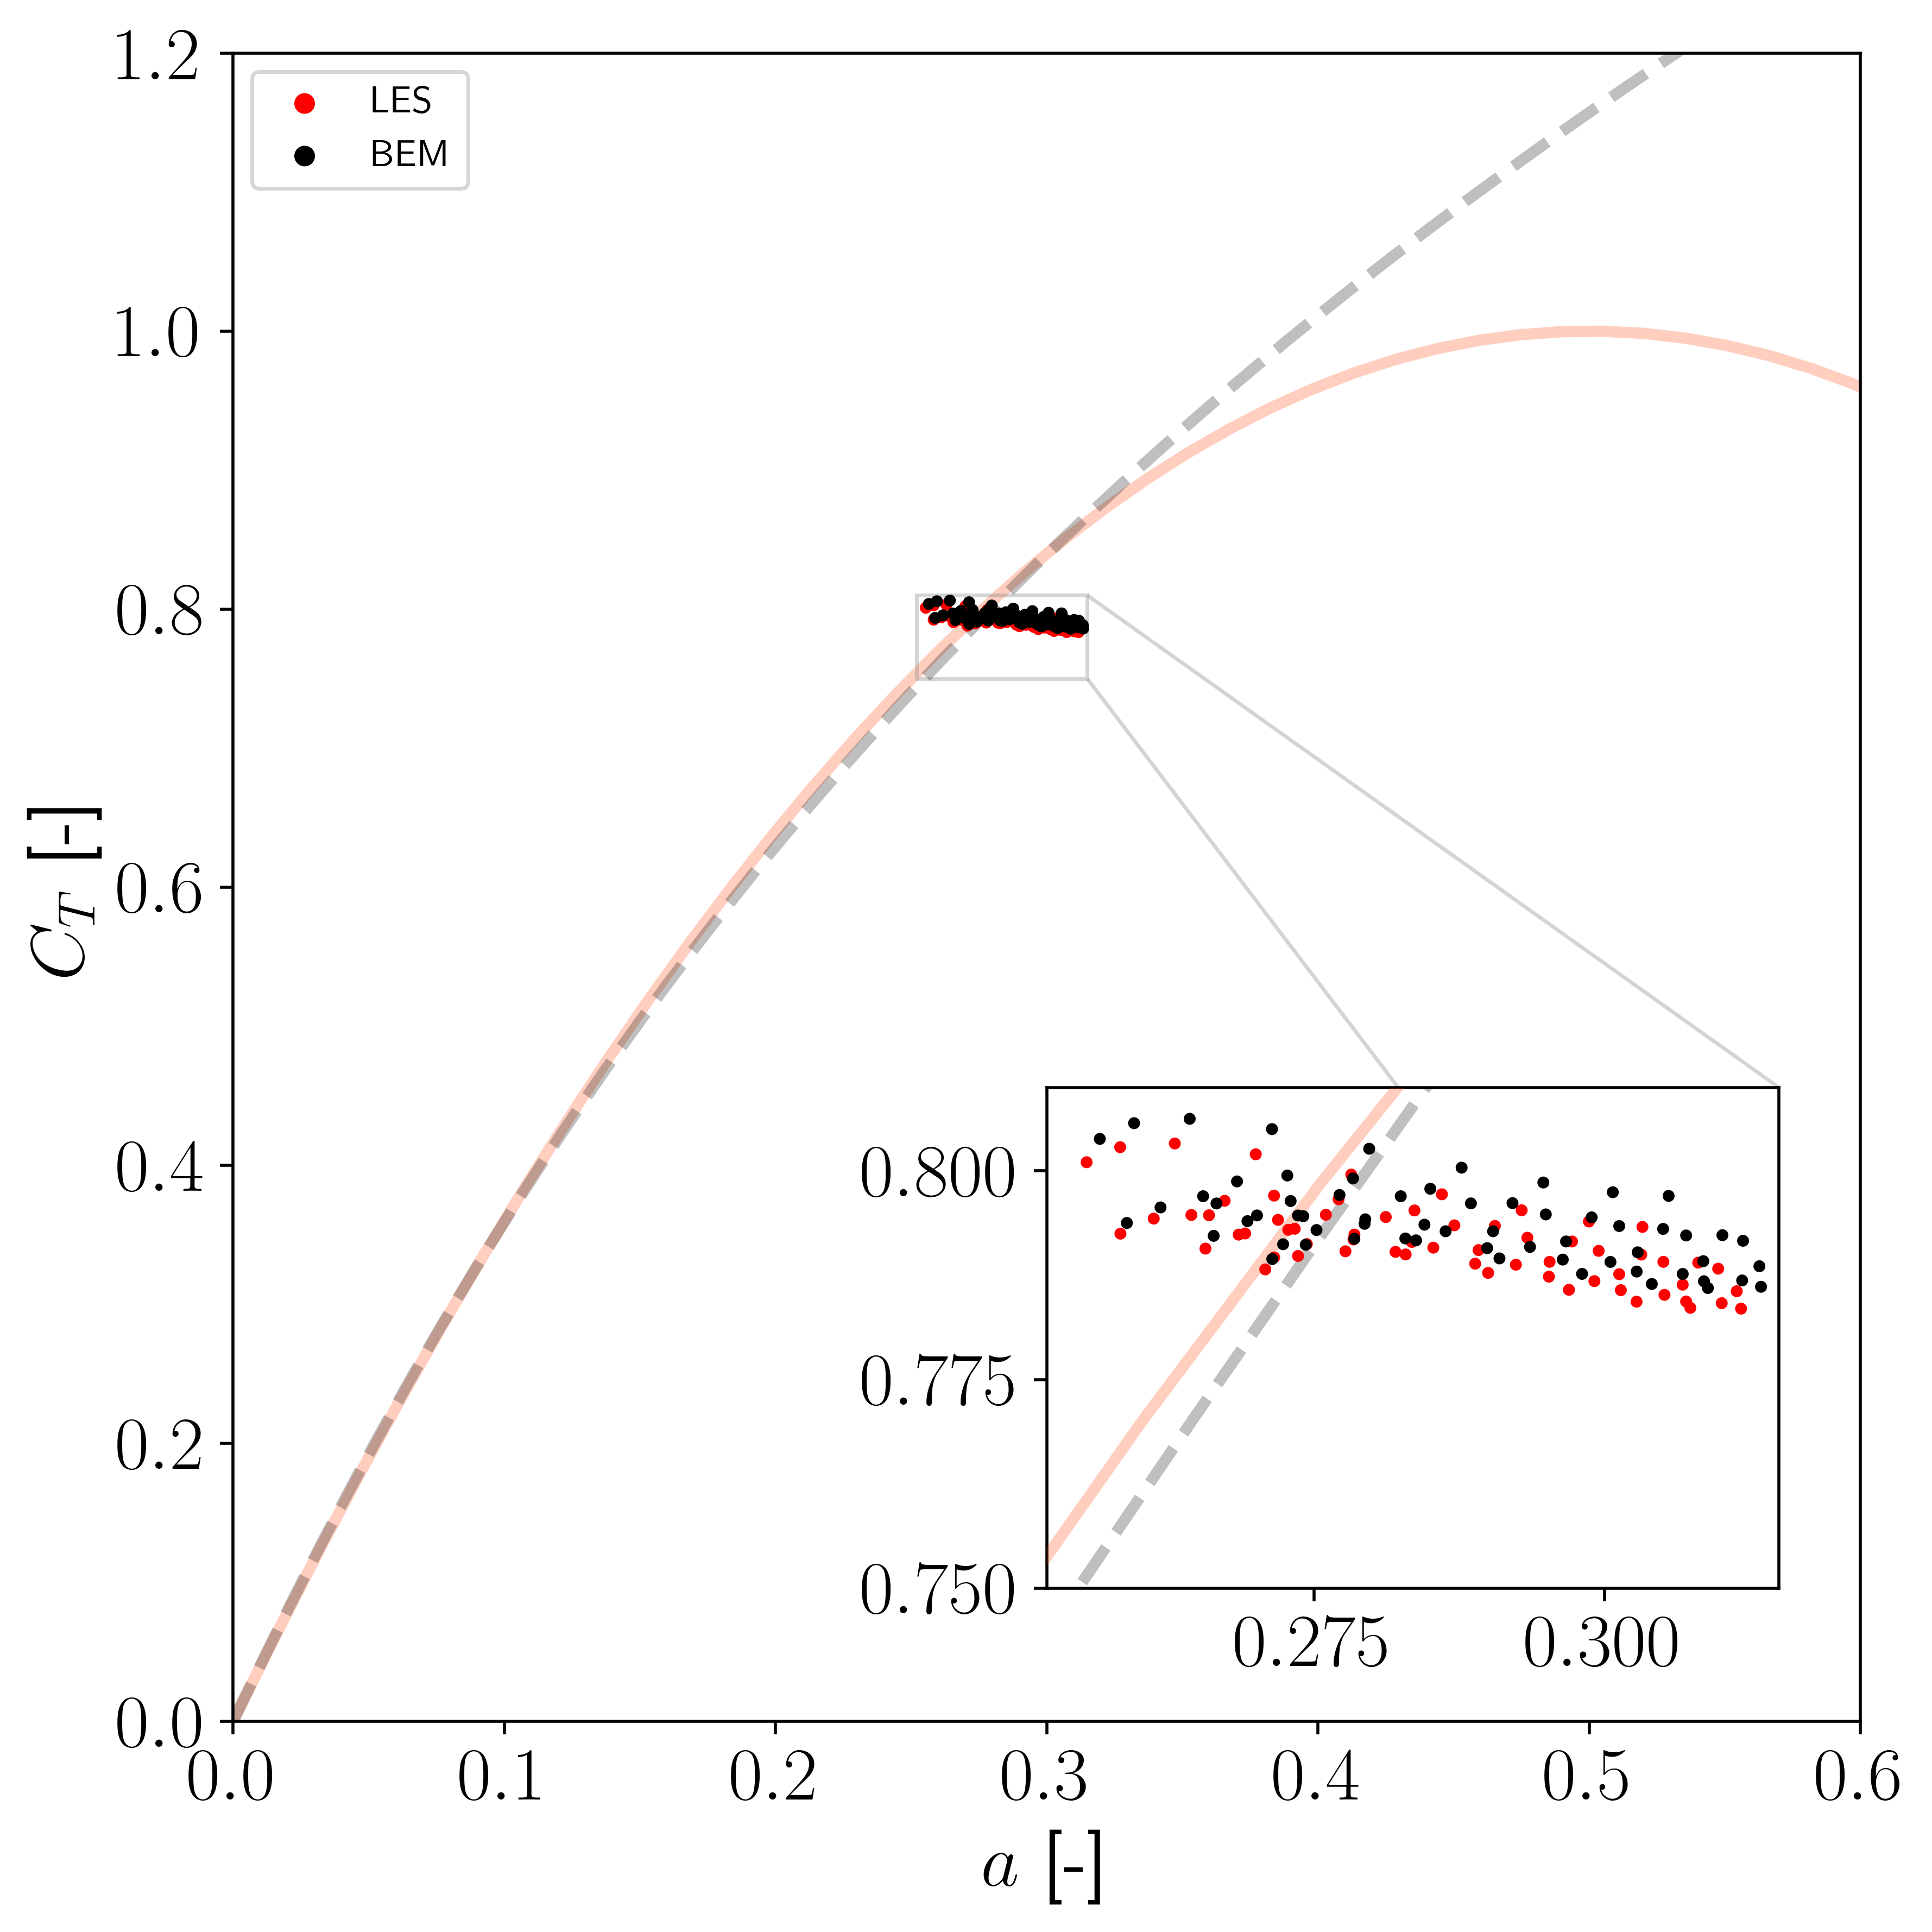

In [77]:
fig, ax = plt.subplots(figsize=(7, 7), constrained_layout=True,sharex=True, sharey=True)

pos_inds = [i for i, (s, v) in enumerate(training) if v >= 0 ]

a_mom  = np.linspace(0,0.75,50)
ct_mom = 4 * a_mom * (1 - a_mom)
ax.plot(a_mom, ct_mom, '#ff3c00',linewidth=3,zorder=1,alpha=0.25)

ct_mad = np.linspace(0,1.5,75)
k1 = 0.2460
k2 = 0.0586
k3 = 0.0883
a_mad = k3 * ct_mad**3 + k2 * ct_mad**2 + k1 * ct_mad
ax.plot(a_mad, ct_mad, 'k--',linewidth=3,zorder=2,alpha=0.25)

ax.scatter(wrf_ind[pos_inds], wrf_cot[pos_inds], s=10, edgecolor='none',color='r',zorder=3)
ax.scatter(mit_ind[pos_inds], mit_cot[pos_inds], s=10, edgecolor='none',color='k',zorder=3)

ax.scatter(-10, -10, s=30, edgecolor='none',color='r',zorder=3,label='LES')
ax.scatter(-10, -10, s=30, edgecolor='none',color='k',zorder=3,label='BEM')

ax.legend()

# === Add inset axes ===
# Example: Zoom into a cluster near a=0.32, CT=0.7

inset_ax = ax.inset_axes(
   [0.5, 0.08, 0.45, 0.3],  # [x, y, width, height] w.r.t. axes
    xlim=[0.252, 0.315], ylim=[0.75, 0.81] # sets viewport & tells relation to main axes
    # xticklabels=[], yticklabels=[]
)

# # Plot the same data inside the inset
inset_ax.plot(a_mom, ct_mom, '#ff3c00', linewidth=3, alpha=0.25,zorder=3)
inset_ax.plot(a_mad, ct_mad, 'k--', linewidth=3, alpha=0.25,zorder=3)

inset_ax.scatter(wrf_ind[pos_inds], wrf_cot[pos_inds], s=10, edgecolor='none',color='r',zorder=3)
inset_ax.scatter(mit_ind[pos_inds], mit_cot[pos_inds], s=10, edgecolor='none',color='k',zorder=3)

rect = patches.Rectangle((0.2, 0.6), 0.2, 0.3, facecolor='white', edgecolor='k',zorder=2)
inset_ax.add_patch(rect)

mark_inset(ax, inset_ax, loc1=1, loc2=4, fc="none", ec="0.5",zorder=1,alpha=1/3)

ax.set_xlim([0,0.6])
ax.set_ylim([0,1.2])

ax.set_ylabel('$C_T$ [-]', fontsize=20)
ax.set_xlabel('$a$ [-]', fontsize=20)

Text(0.5, 0, '$a$ [-]')

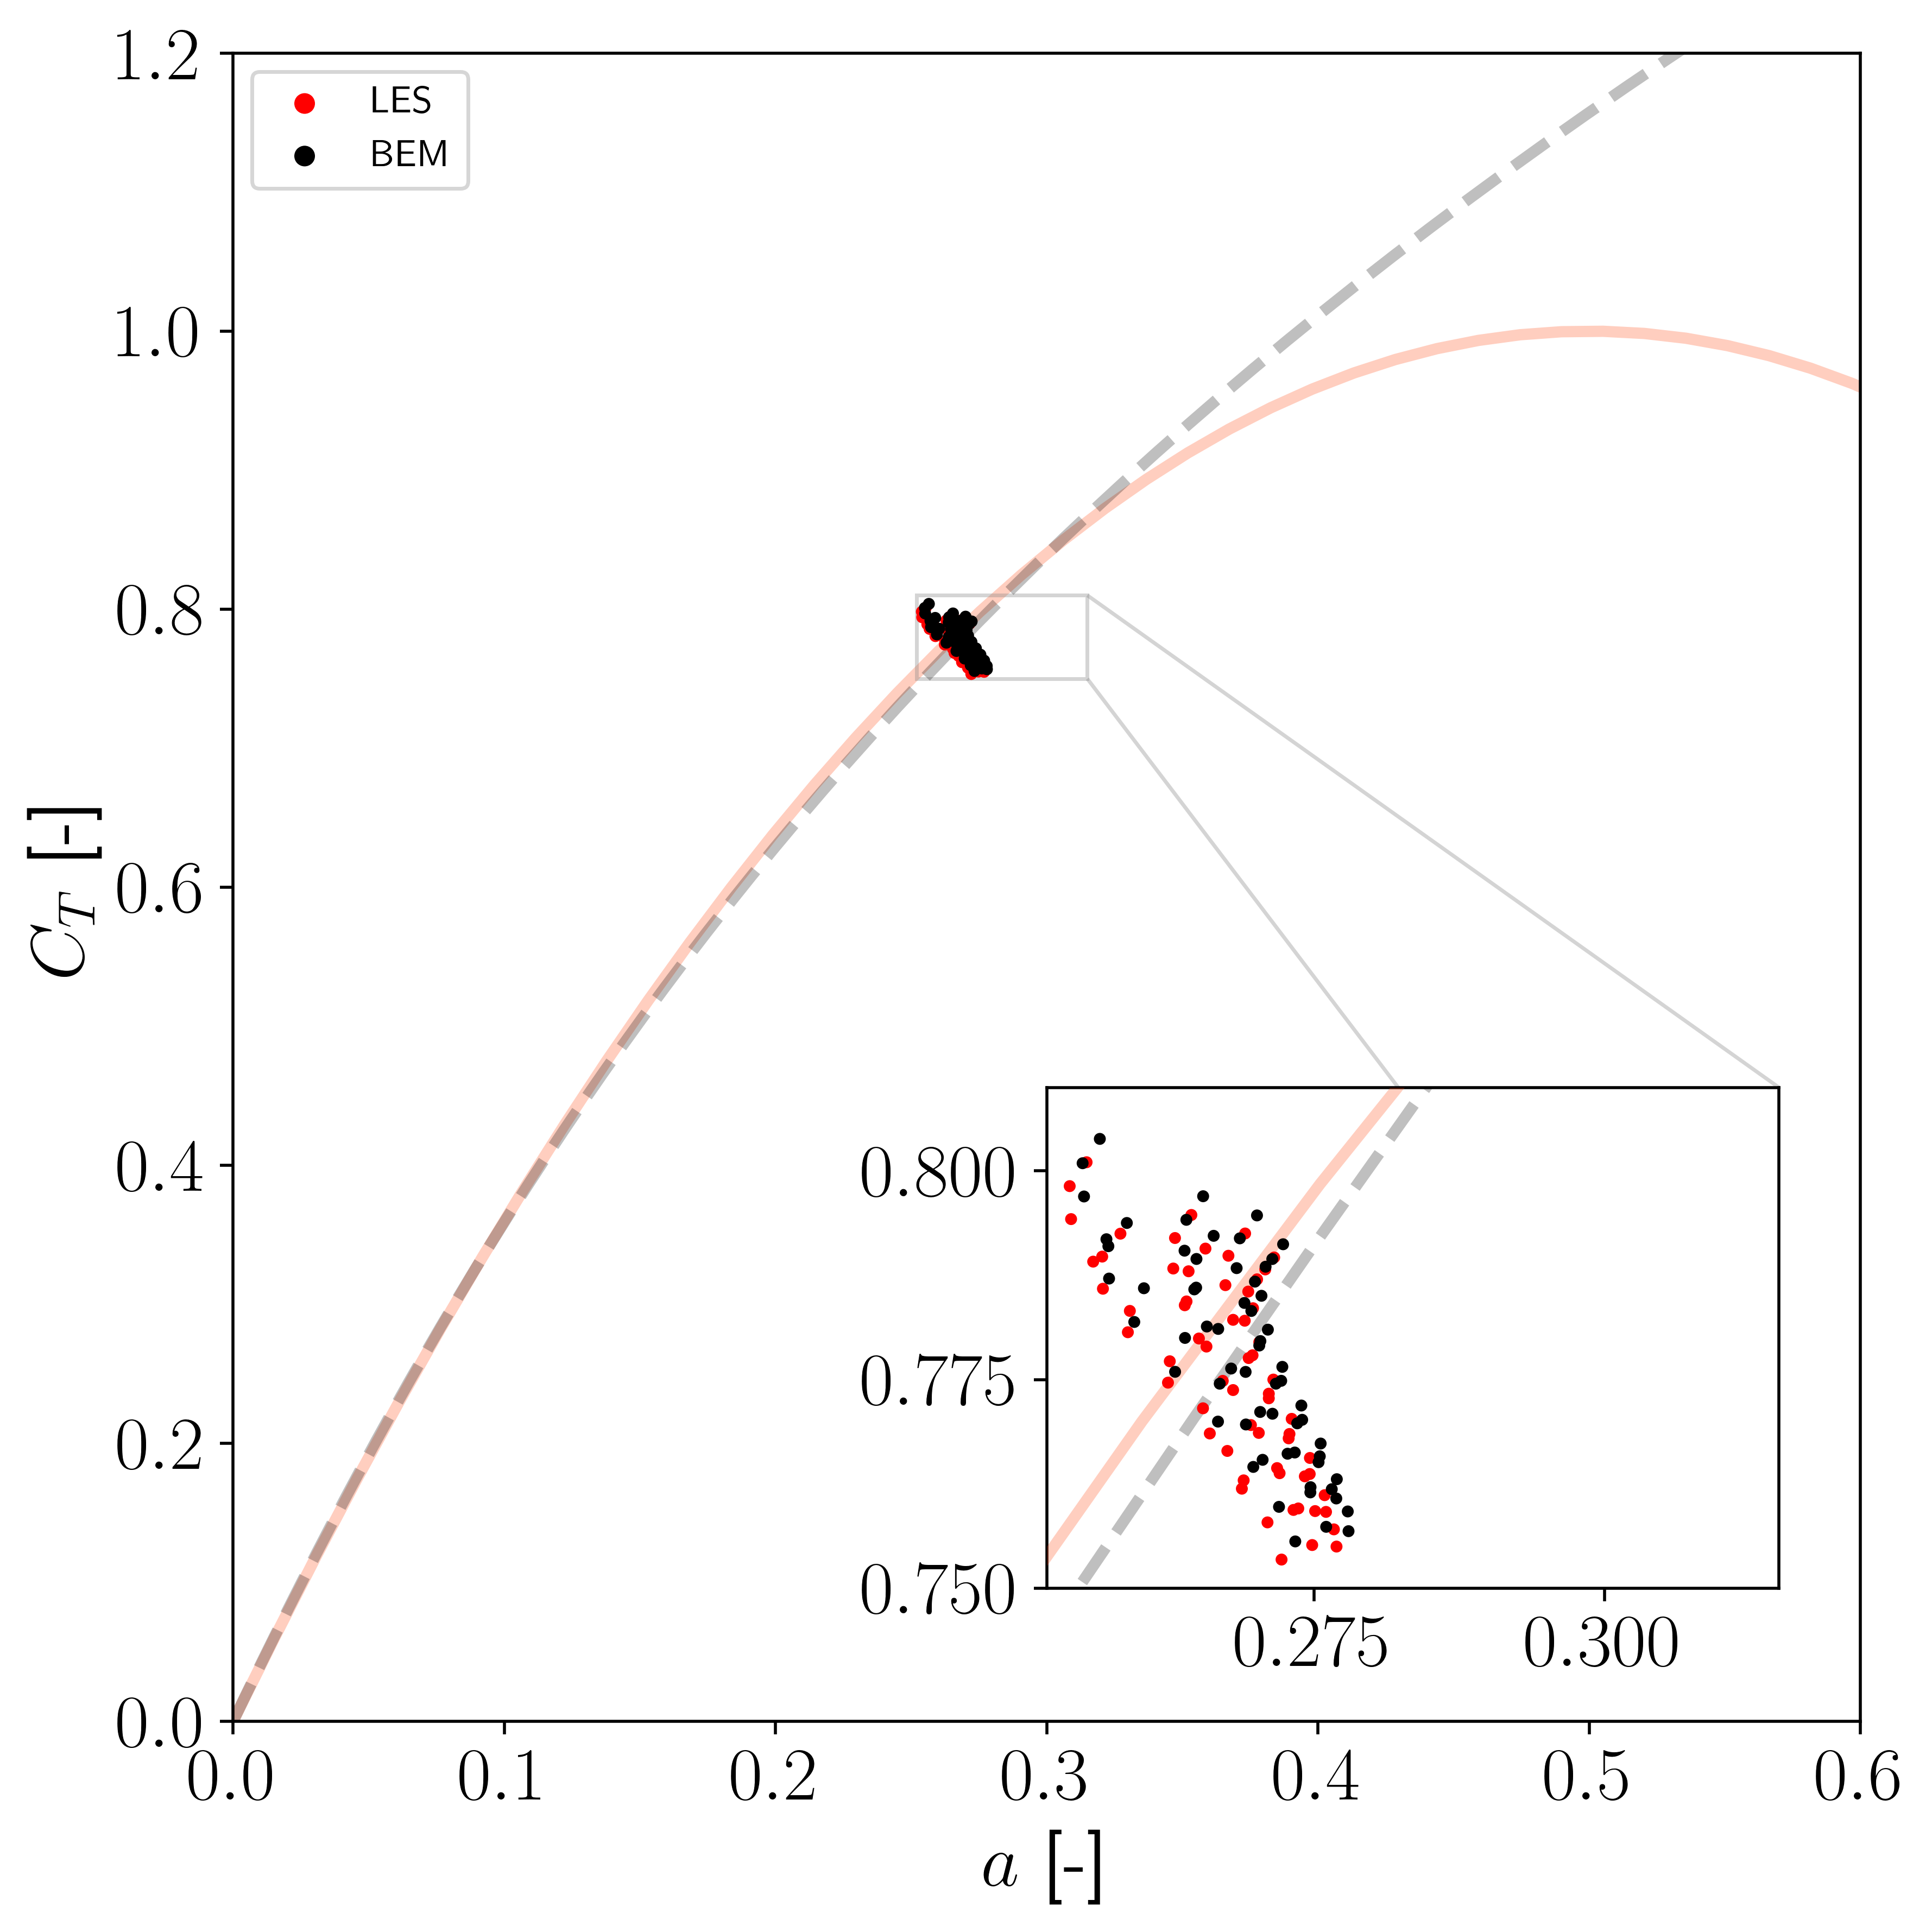

In [78]:
fig, ax = plt.subplots(figsize=(7, 7), constrained_layout=True,sharex=True, sharey=True)

neg_inds = [i for i, (s, v) in enumerate(training) if v <= 0 ]

a_mom  = np.linspace(0,0.75,50)
ct_mom = 4 * a_mom * (1 - a_mom)
ax.plot(a_mom, ct_mom, '#ff3c00',linewidth=3,zorder=1,alpha=0.25)

ct_mad = np.linspace(0,1.5,75)
k1 = 0.2460
k2 = 0.0586
k3 = 0.0883
a_mad = k3 * ct_mad**3 + k2 * ct_mad**2 + k1 * ct_mad
ax.plot(a_mad, ct_mad, 'k--',linewidth=3,zorder=2,alpha=0.25)

ax.scatter(wrf_ind[neg_inds], wrf_cot[neg_inds], s=10, edgecolor='none',color='r',zorder=3)
ax.scatter(mit_ind[neg_inds], mit_cot[neg_inds], s=10, edgecolor='none',color='k',zorder=3)

ax.scatter(-10, -10, s=30, edgecolor='none',color='r',zorder=3,label='LES')
ax.scatter(-10, -10, s=30, edgecolor='none',color='k',zorder=3,label='BEM')

ax.legend()

# === Add inset axes ===
# Example: Zoom into a cluster near a=0.32, CT=0.7

inset_ax = ax.inset_axes(
   [0.5, 0.08, 0.45, 0.3],  # [x, y, width, height] w.r.t. axes
    xlim=[0.252, 0.315], ylim=[0.75, 0.81] # sets viewport & tells relation to main axes
    # xticklabels=[], yticklabels=[]
)

# # Plot the same data inside the inset
inset_ax.plot(a_mom, ct_mom, '#ff3c00', linewidth=3, alpha=0.25,zorder=3)
inset_ax.plot(a_mad, ct_mad, 'k--', linewidth=3, alpha=0.25,zorder=3)

inset_ax.scatter(wrf_ind[neg_inds], wrf_cot[neg_inds], s=10, edgecolor='none',color='r',zorder=3)
inset_ax.scatter(mit_ind[neg_inds], mit_cot[neg_inds], s=10, edgecolor='none',color='k',zorder=3)

rect = patches.Rectangle((0.2, 0.6), 0.2, 0.3, facecolor='white', edgecolor='k',zorder=2)
inset_ax.add_patch(rect)

mark_inset(ax, inset_ax, loc1=1, loc2=4, fc="none", ec="0.5",zorder=1,alpha=1/3)

ax.set_xlim([0,0.6])
ax.set_ylim([0,1.2])

ax.set_ylabel('$C_T$ [-]', fontsize=20)
ax.set_xlabel('$a$ [-]', fontsize=20)

Text(0.5, 0, '$a$ [-]')

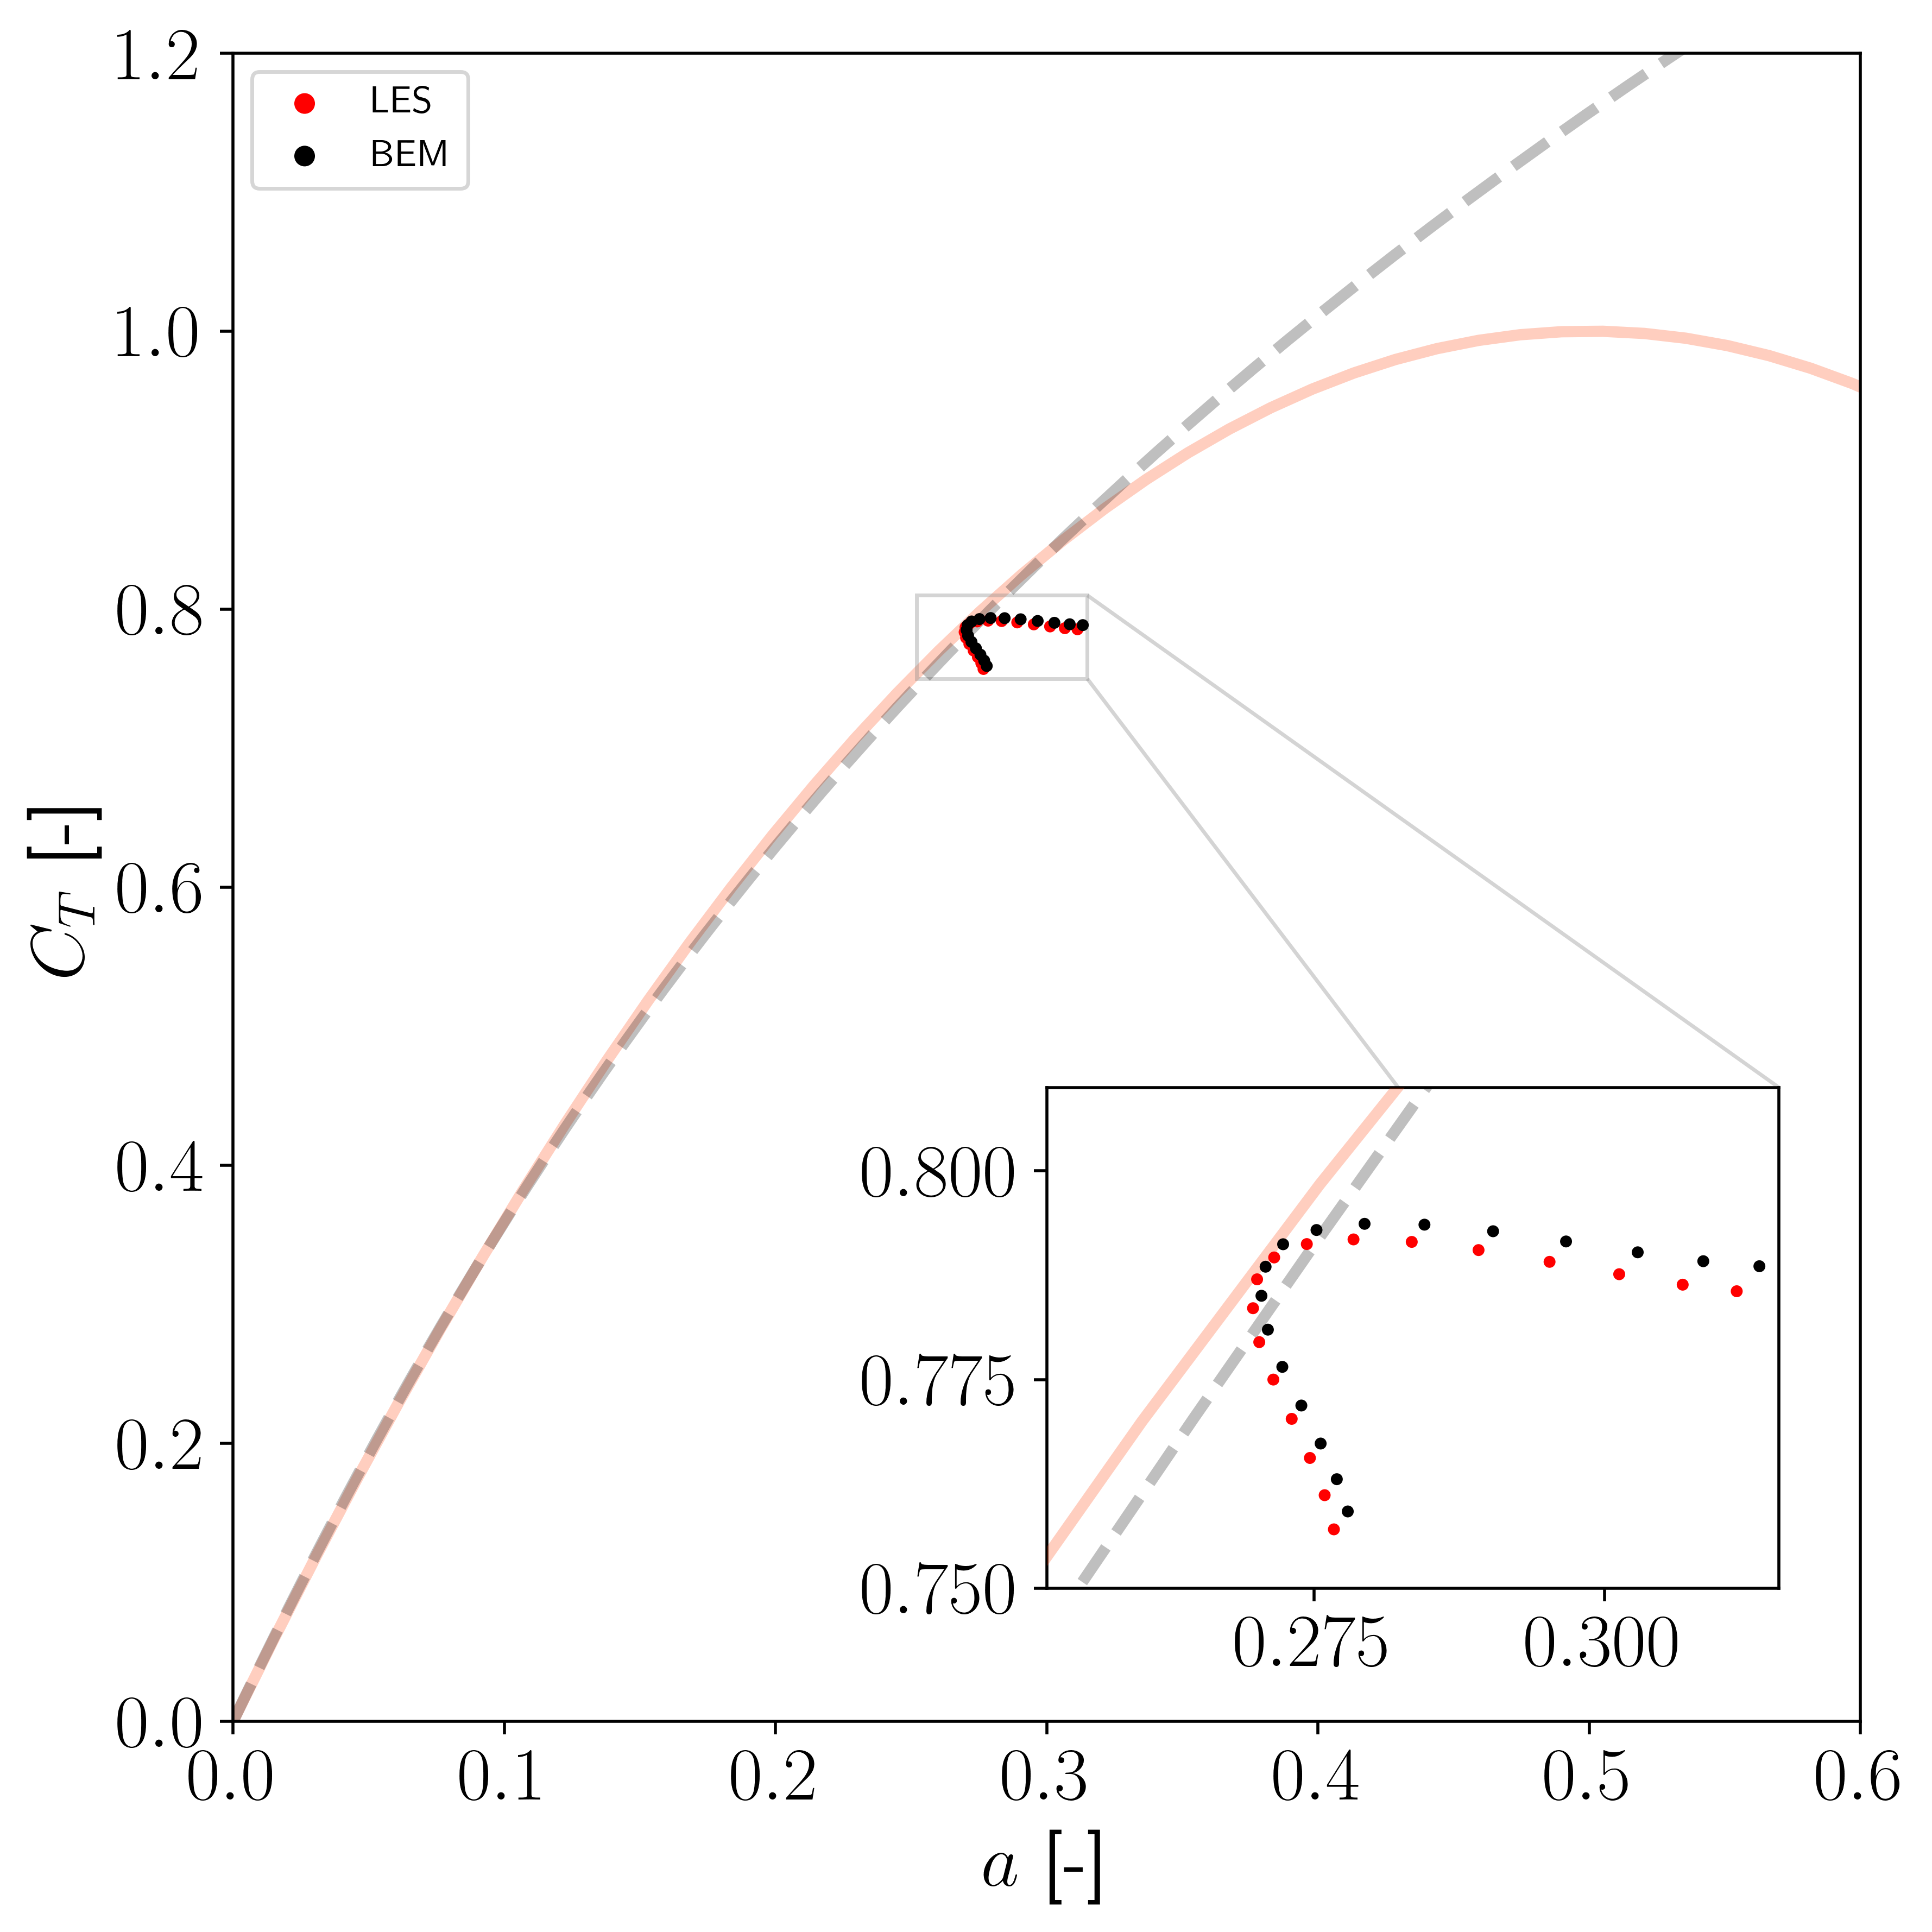

In [79]:
fig, ax = plt.subplots(figsize=(7, 7), constrained_layout=True,sharex=True, sharey=True)

s0_inds = [i for i, (s, v) in enumerate(training) if abs(s) == 0 ]

a_mom  = np.linspace(0,0.75,50)
ct_mom = 4 * a_mom * (1 - a_mom)
ax.plot(a_mom, ct_mom, '#ff3c00',linewidth=3,zorder=1,alpha=0.25)

ct_mad = np.linspace(0,1.5,75)
k1 = 0.2460
k2 = 0.0586
k3 = 0.0883
a_mad = k3 * ct_mad**3 + k2 * ct_mad**2 + k1 * ct_mad
ax.plot(a_mad, ct_mad, 'k--',linewidth=3,zorder=2,alpha=0.25)

ax.scatter(wrf_ind[s0_inds], wrf_cot[s0_inds], s=10, edgecolor='none',color='r',zorder=3)
ax.scatter(mit_ind[s0_inds], mit_cot[s0_inds], s=10, edgecolor='none',color='k',zorder=3)

ax.scatter(-10, -10, s=30, edgecolor='none',color='r',zorder=3,label='LES')
ax.scatter(-10, -10, s=30, edgecolor='none',color='k',zorder=3,label='BEM')

ax.legend()

# === Add inset axes ===
# Example: Zoom into a cluster near a=0.32, CT=0.7

inset_ax = ax.inset_axes(
   [0.5, 0.08, 0.45, 0.3],  # [x, y, width, height] w.r.t. axes
    xlim=[0.252, 0.315], ylim=[0.75, 0.81] # sets viewport & tells relation to main axes
    # xticklabels=[], yticklabels=[]
)

# # Plot the same data inside the inset
inset_ax.plot(a_mom, ct_mom, '#ff3c00', linewidth=3, alpha=0.25,zorder=3)
inset_ax.plot(a_mad, ct_mad, 'k--', linewidth=3, alpha=0.25,zorder=3)

inset_ax.scatter(wrf_ind[s0_inds], wrf_cot[s0_inds], s=10, edgecolor='none',color='r',zorder=3)
inset_ax.scatter(mit_ind[s0_inds], mit_cot[s0_inds], s=10, edgecolor='none',color='k',zorder=3)

rect = patches.Rectangle((0.2, 0.6), 0.2, 0.3, facecolor='white', edgecolor='k',zorder=2)
inset_ax.add_patch(rect)

mark_inset(ax, inset_ax, loc1=1, loc2=4, fc="none", ec="0.5",zorder=1,alpha=1/3)

ax.set_xlim([0,0.6])
ax.set_ylim([0,1.2])

ax.set_ylabel('$C_T$ [-]', fontsize=20)
ax.set_xlabel('$a$ [-]', fontsize=20)

Text(0.5, 0, '$a$ [-]')

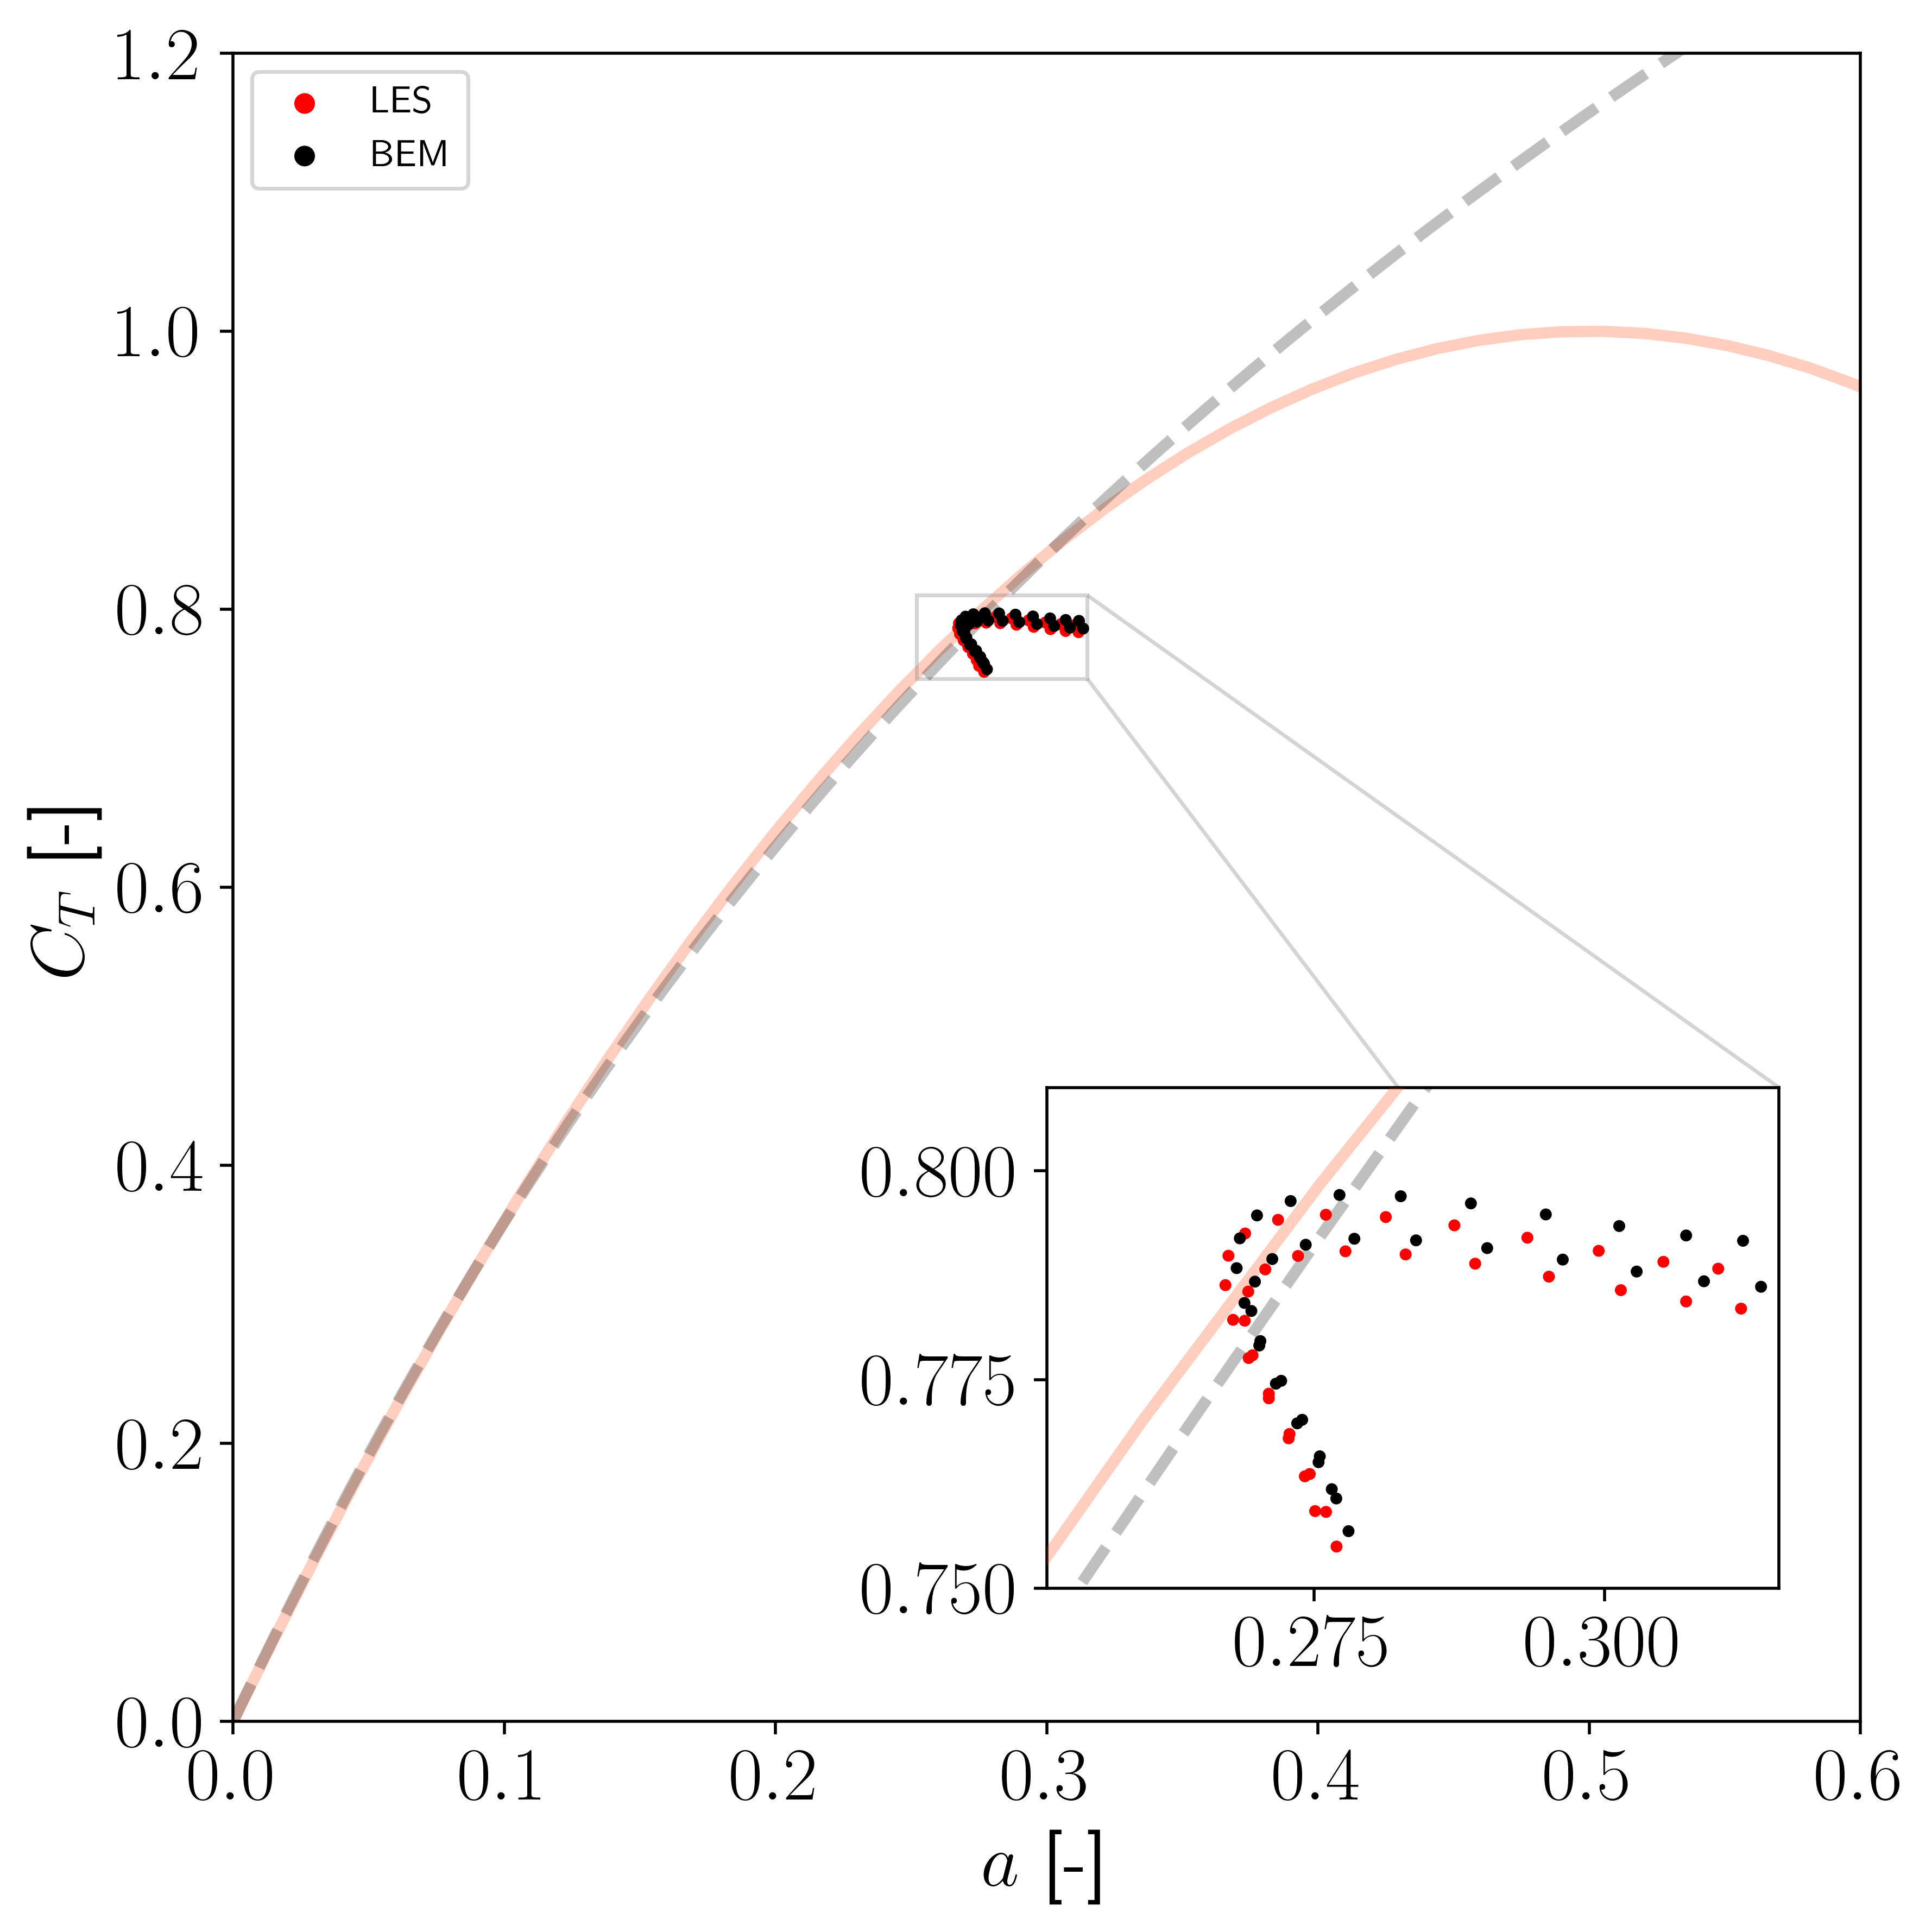

In [80]:
fig, ax = plt.subplots(figsize=(7, 7), constrained_layout=True,sharex=True, sharey=True)

s2_inds = [i for i, (s, v) in enumerate(training) if abs(s) == 2 ]

a_mom  = np.linspace(0,0.75,50)
ct_mom = 4 * a_mom * (1 - a_mom)
ax.plot(a_mom, ct_mom, '#ff3c00',linewidth=3,zorder=1,alpha=0.25)

ct_mad = np.linspace(0,1.5,75)
k1 = 0.2460
k2 = 0.0586
k3 = 0.0883
a_mad = k3 * ct_mad**3 + k2 * ct_mad**2 + k1 * ct_mad
ax.plot(a_mad, ct_mad, 'k--',linewidth=3,zorder=2,alpha=0.25)

ax.scatter(wrf_ind[s2_inds], wrf_cot[s2_inds], s=10, edgecolor='none',color='r',zorder=3)
ax.scatter(mit_ind[s2_inds], mit_cot[s2_inds], s=10, edgecolor='none',color='k',zorder=3)

ax.scatter(-10, -10, s=30, edgecolor='none',color='r',zorder=3,label='LES')
ax.scatter(-10, -10, s=30, edgecolor='none',color='k',zorder=3,label='BEM')

ax.legend()

# === Add inset axes ===
# Example: Zoom into a cluster near a=0.32, CT=0.7

inset_ax = ax.inset_axes(
   [0.5, 0.08, 0.45, 0.3],  # [x, y, width, height] w.r.t. axes
    xlim=[0.252, 0.315], ylim=[0.75, 0.81] # sets viewport & tells relation to main axes
    # xticklabels=[], yticklabels=[]
)

# # Plot the same data inside the inset
inset_ax.plot(a_mom, ct_mom, '#ff3c00', linewidth=3, alpha=0.25,zorder=3)
inset_ax.plot(a_mad, ct_mad, 'k--', linewidth=3, alpha=0.25,zorder=3)

inset_ax.scatter(wrf_ind[s2_inds], wrf_cot[s2_inds], s=10, edgecolor='none',color='r',zorder=3)
inset_ax.scatter(mit_ind[s2_inds], mit_cot[s2_inds], s=10, edgecolor='none',color='k',zorder=3)

rect = patches.Rectangle((0.2, 0.6), 0.2, 0.3, facecolor='white', edgecolor='k',zorder=2)
inset_ax.add_patch(rect)

mark_inset(ax, inset_ax, loc1=1, loc2=4, fc="none", ec="0.5",zorder=1,alpha=1/3)

ax.set_xlim([0,0.6])
ax.set_ylim([0,1.2])

ax.set_ylabel('$C_T$ [-]', fontsize=20)
ax.set_xlabel('$a$ [-]', fontsize=20)

Text(0.5, 0, '$a$ [-]')

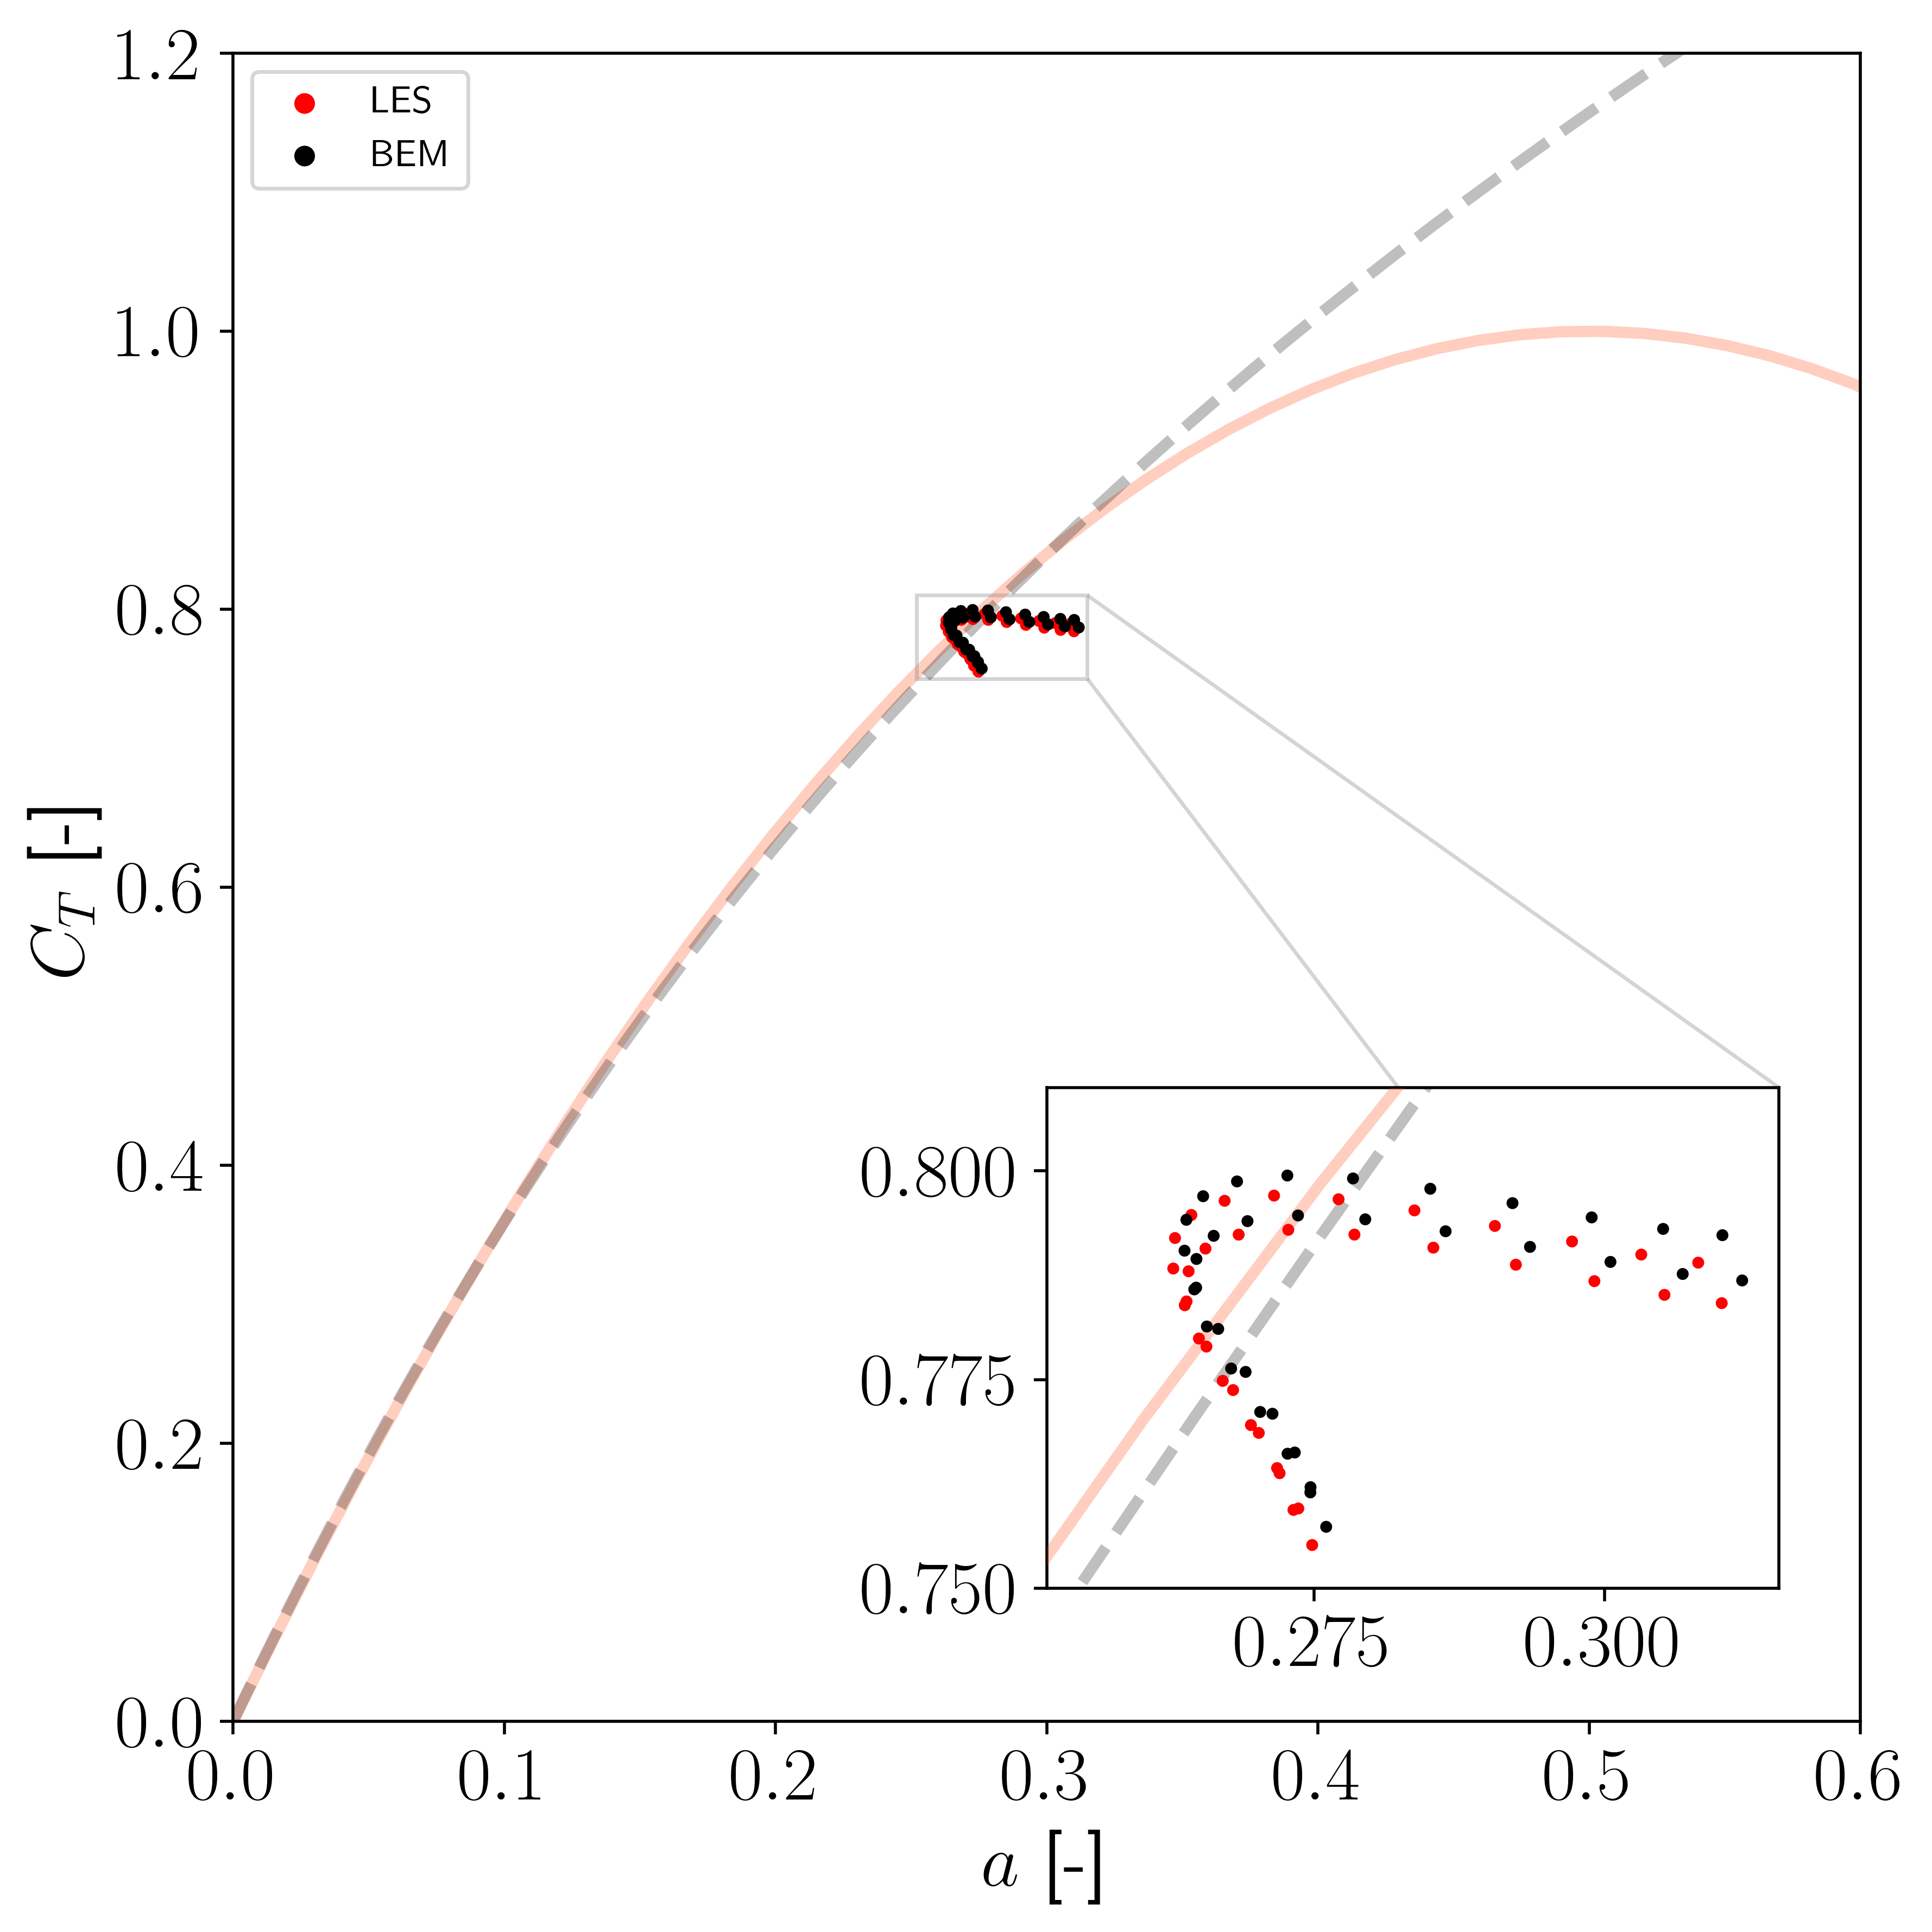

In [81]:
fig, ax = plt.subplots(figsize=(7, 7), constrained_layout=True,sharex=True, sharey=True)

s4_inds = [i for i, (s, v) in enumerate(training) if abs(s) == 4 ]

a_mom  = np.linspace(0,0.75,50)
ct_mom = 4 * a_mom * (1 - a_mom)
ax.plot(a_mom, ct_mom, '#ff3c00',linewidth=3,zorder=1,alpha=0.25)

ct_mad = np.linspace(0,1.5,75)
k1 = 0.2460
k2 = 0.0586
k3 = 0.0883
a_mad = k3 * ct_mad**3 + k2 * ct_mad**2 + k1 * ct_mad
ax.plot(a_mad, ct_mad, 'k--',linewidth=3,zorder=2,alpha=0.25)

ax.scatter(wrf_ind[s4_inds], wrf_cot[s4_inds], s=10, edgecolor='none',color='r',zorder=3)
ax.scatter(mit_ind[s4_inds], mit_cot[s4_inds], s=10, edgecolor='none',color='k',zorder=3)

ax.scatter(-10, -10, s=30, edgecolor='none',color='r',zorder=3,label='LES')
ax.scatter(-10, -10, s=30, edgecolor='none',color='k',zorder=3,label='BEM')

ax.legend()

# === Add inset axes ===
# Example: Zoom into a cluster near a=0.32, CT=0.7

inset_ax = ax.inset_axes(
   [0.5, 0.08, 0.45, 0.3],  # [x, y, width, height] w.r.t. axes
    xlim=[0.252, 0.315], ylim=[0.75, 0.81] # sets viewport & tells relation to main axes
    # xticklabels=[], yticklabels=[]
)

# # Plot the same data inside the inset
inset_ax.plot(a_mom, ct_mom, '#ff3c00', linewidth=3, alpha=0.25,zorder=3)
inset_ax.plot(a_mad, ct_mad, 'k--', linewidth=3, alpha=0.25,zorder=3)

inset_ax.scatter(wrf_ind[s4_inds], wrf_cot[s4_inds], s=10, edgecolor='none',color='r',zorder=3)
inset_ax.scatter(mit_ind[s4_inds], mit_cot[s4_inds], s=10, edgecolor='none',color='k',zorder=3)

rect = patches.Rectangle((0.2, 0.6), 0.2, 0.3, facecolor='white', edgecolor='k',zorder=2)
inset_ax.add_patch(rect)

mark_inset(ax, inset_ax, loc1=1, loc2=4, fc="none", ec="0.5",zorder=1,alpha=1/3)

ax.set_xlim([0,0.6])
ax.set_ylim([0,1.2])

ax.set_ylabel('$C_T$ [-]', fontsize=20)
ax.set_xlabel('$a$ [-]', fontsize=20)

Text(0.5, 0, '$a$ [-]')

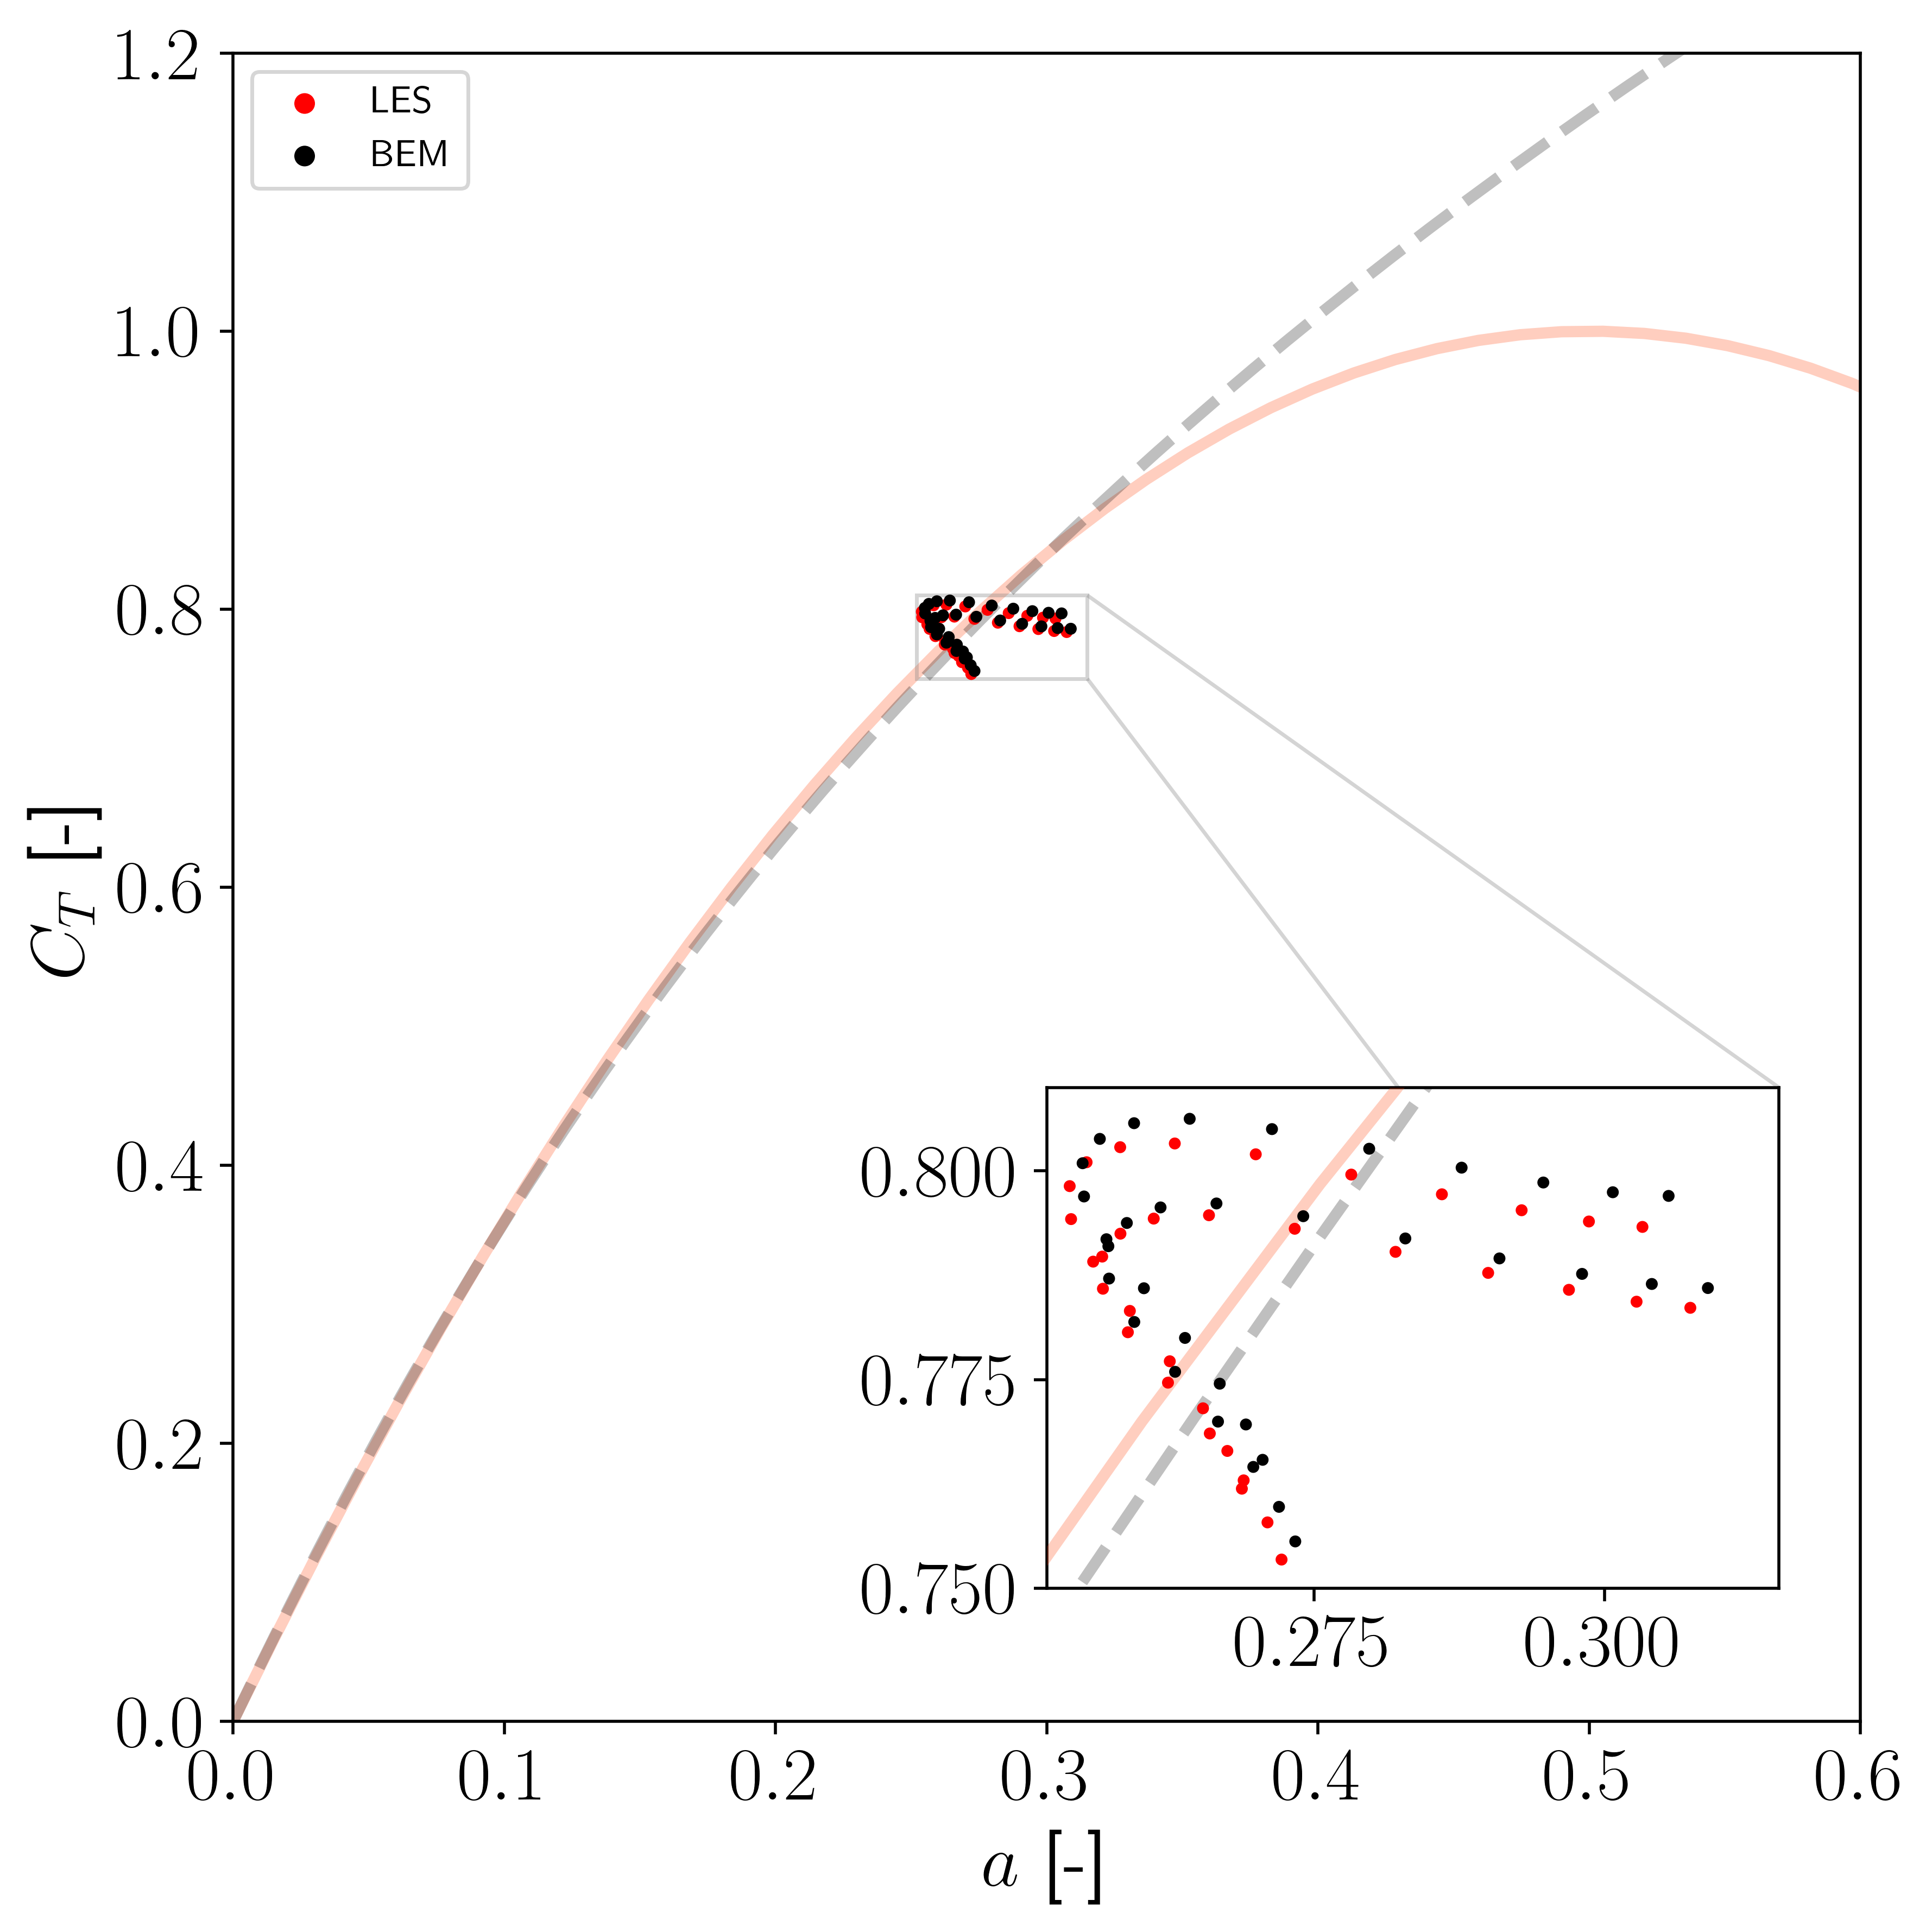

In [82]:
fig, ax = plt.subplots(figsize=(7, 7), constrained_layout=True,sharex=True, sharey=True)

s6_inds = [i for i, (s, v) in enumerate(training) if abs(s) == 6 ]

a_mom  = np.linspace(0,0.75,50)
ct_mom = 4 * a_mom * (1 - a_mom)
ax.plot(a_mom, ct_mom, '#ff3c00',linewidth=3,zorder=1,alpha=0.25)

ct_mad = np.linspace(0,1.5,75)
k1 = 0.2460
k2 = 0.0586
k3 = 0.0883
a_mad = k3 * ct_mad**3 + k2 * ct_mad**2 + k1 * ct_mad
ax.plot(a_mad, ct_mad, 'k--',linewidth=3,zorder=2,alpha=0.25)

ax.scatter(wrf_ind[s6_inds], wrf_cot[s6_inds], s=10, edgecolor='none',color='r',zorder=3)
ax.scatter(mit_ind[s6_inds], mit_cot[s6_inds], s=10, edgecolor='none',color='k',zorder=3)

ax.scatter(-10, -10, s=30, edgecolor='none',color='r',zorder=3,label='LES')
ax.scatter(-10, -10, s=30, edgecolor='none',color='k',zorder=3,label='BEM')

ax.legend()

# === Add inset axes ===
# Example: Zoom into a cluster near a=0.32, CT=0.7

inset_ax = ax.inset_axes(
   [0.5, 0.08, 0.45, 0.3],  # [x, y, width, height] w.r.t. axes
    xlim=[0.252, 0.315], ylim=[0.75, 0.81] # sets viewport & tells relation to main axes
    # xticklabels=[], yticklabels=[]
)

# # Plot the same data inside the inset
inset_ax.plot(a_mom, ct_mom, '#ff3c00', linewidth=3, alpha=0.25,zorder=3)
inset_ax.plot(a_mad, ct_mad, 'k--', linewidth=3, alpha=0.25,zorder=3)

inset_ax.scatter(wrf_ind[s6_inds], wrf_cot[s6_inds], s=10, edgecolor='none',color='r',zorder=3)
inset_ax.scatter(mit_ind[s6_inds], mit_cot[s6_inds], s=10, edgecolor='none',color='k',zorder=3)

rect = patches.Rectangle((0.2, 0.6), 0.2, 0.3, facecolor='white', edgecolor='k',zorder=2)
inset_ax.add_patch(rect)

mark_inset(ax, inset_ax, loc1=1, loc2=4, fc="none", ec="0.5",zorder=1,alpha=1/3)

ax.set_xlim([0,0.6])
ax.set_ylim([0,1.2])

ax.set_ylabel('$C_T$ [-]', fontsize=20)
ax.set_xlabel('$a$ [-]', fontsize=20)

Text(0.5, 0, '$a$ [-]')

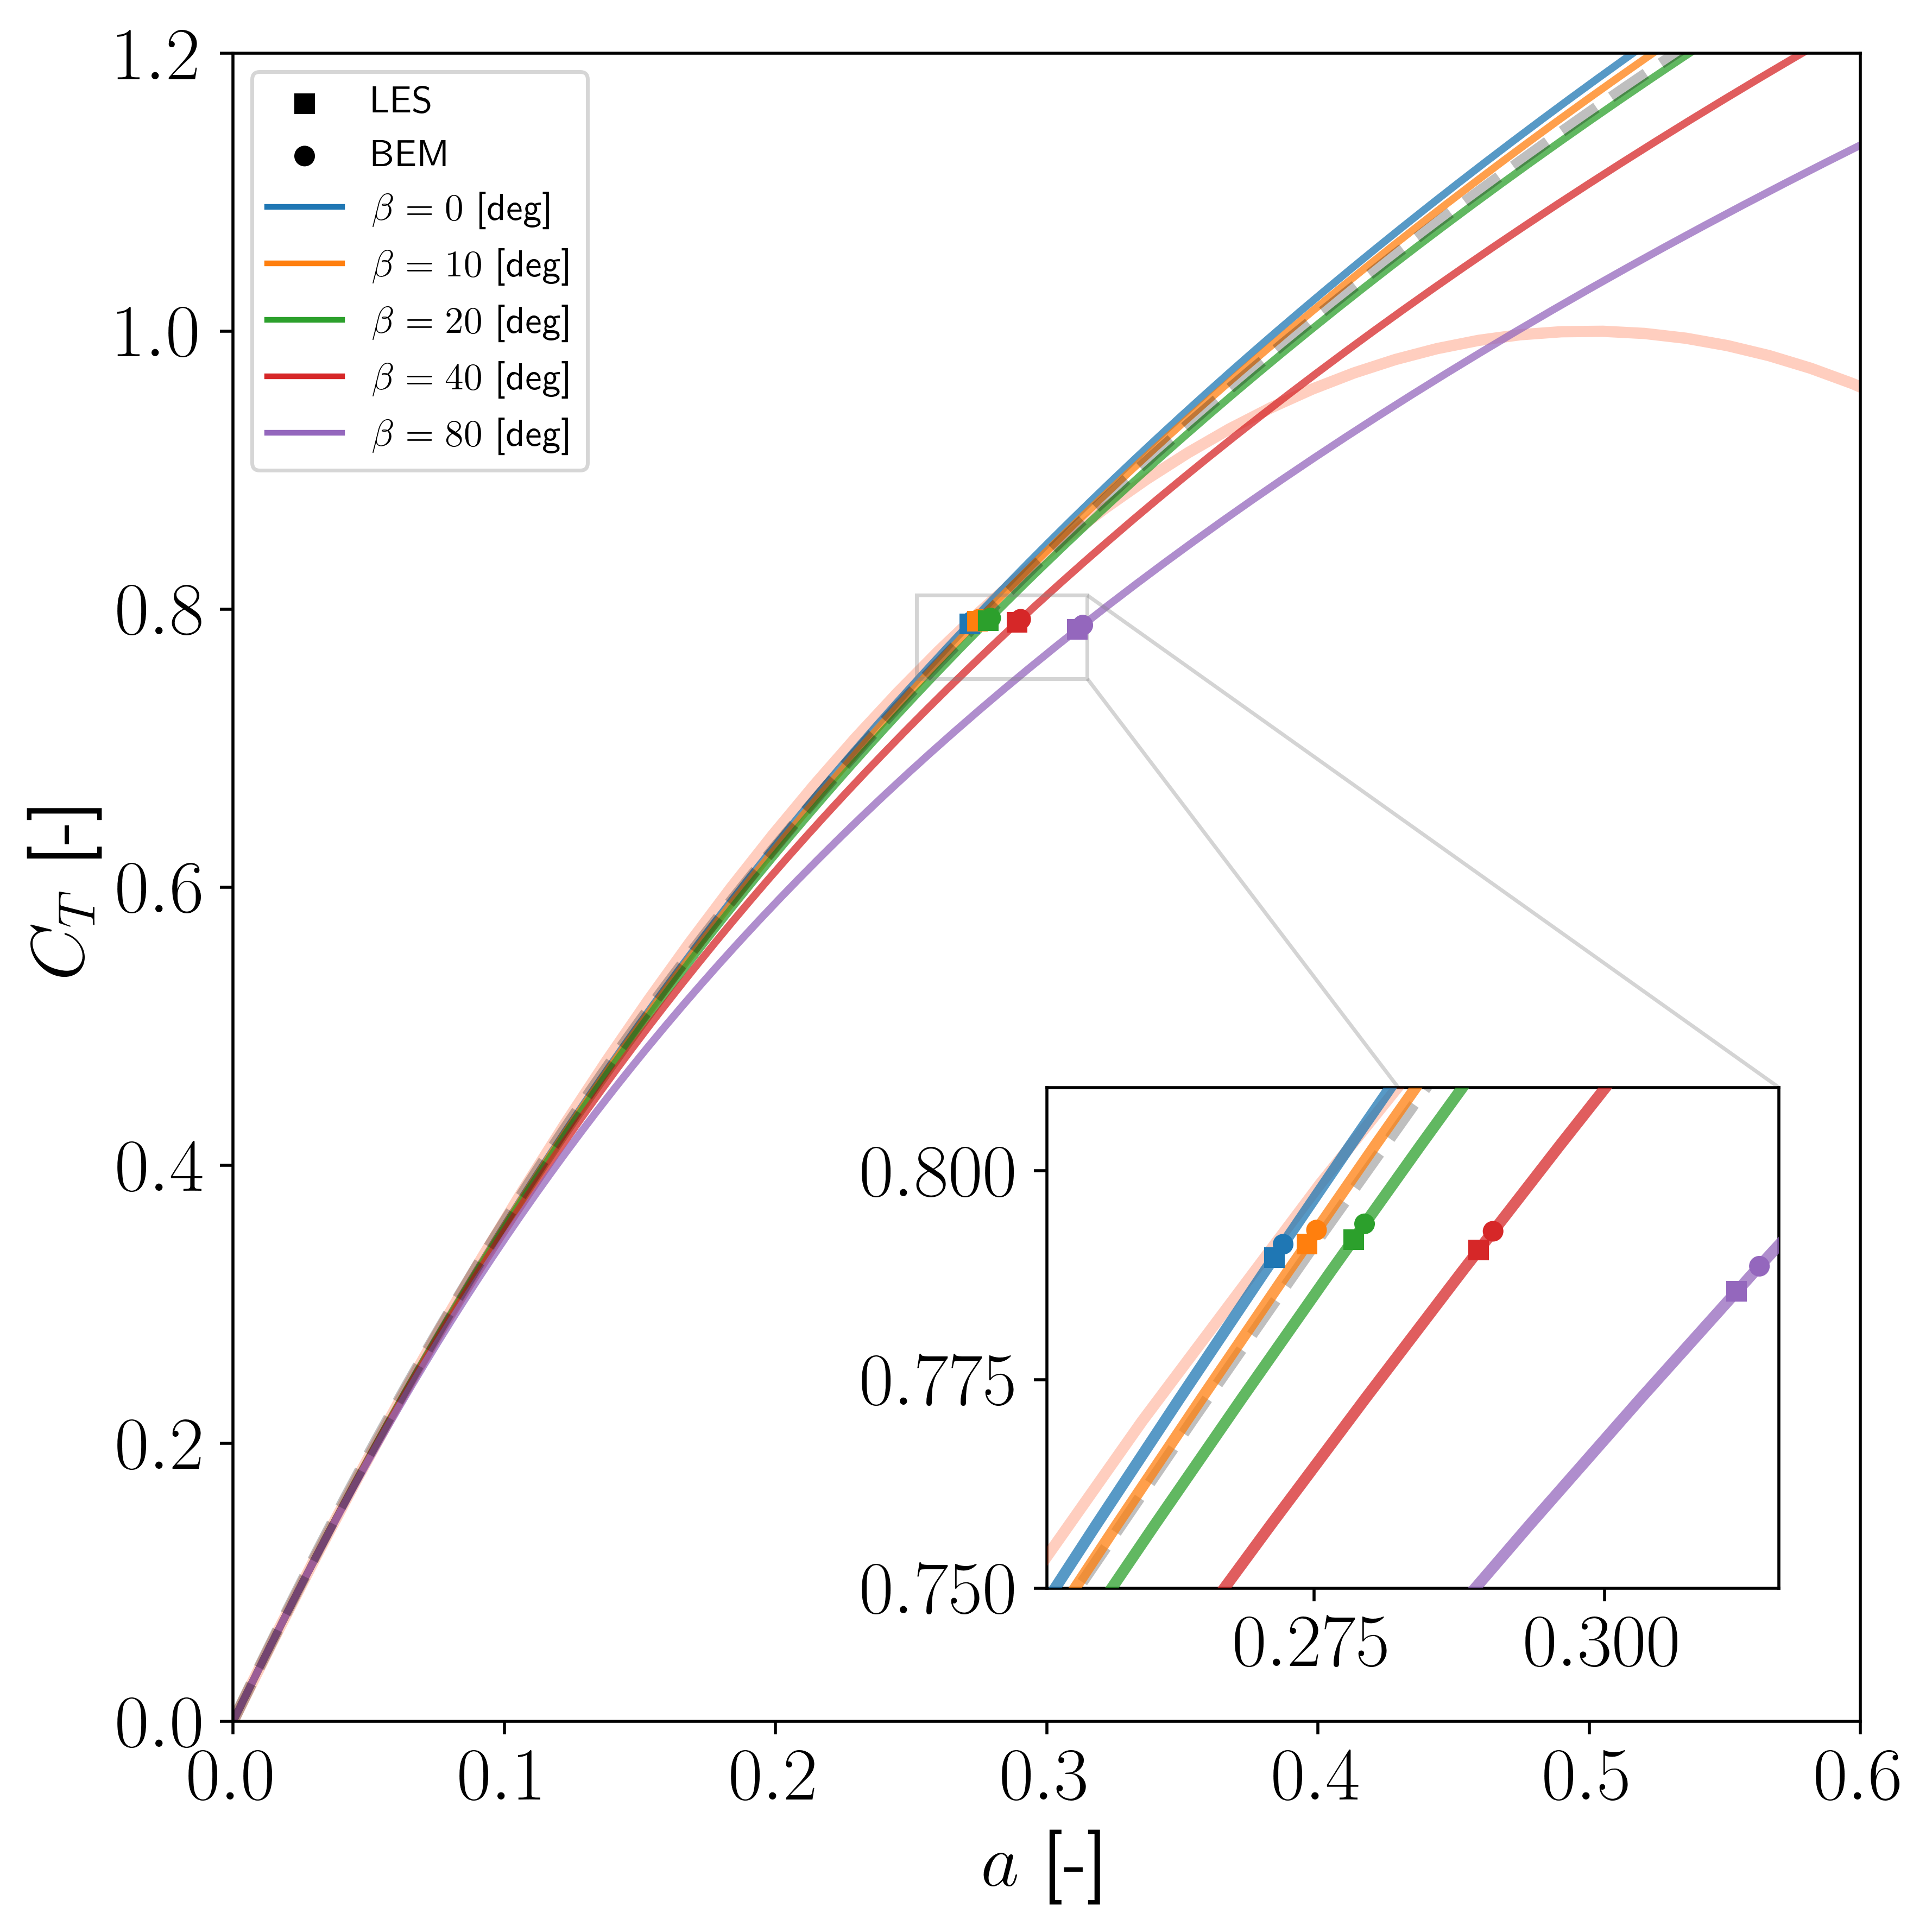

In [83]:
fig, ax = plt.subplots(figsize=(7, 7), constrained_layout=True,sharex=True, sharey=True)

colors = sns.color_palette("tab10", 5)

allowed_values = [0, 10, 20, 40, 80]
inds = [i for i, (s, v) in enumerate(training) if (v in allowed_values and abs(s) == 0)]

a_mom  = np.linspace(0,0.75,50)
ct_mom = 4 * a_mom * (1 - a_mom)
ax.plot(a_mom, ct_mom, '#ff3c00',linewidth=3,zorder=1,alpha=0.25)

ct_mad = np.linspace(0,1.5,75)
k1 = 0.2460
k2 = 0.0586
k3 = 0.0883
a_mad = k3 * ct_mad**3 + k2 * ct_mad**2 + k1 * ct_mad
ax.plot(a_mad, ct_mad, 'k--',linewidth=3,zorder=2,alpha=0.25)

ax.scatter(-10, -10, s=30, edgecolor='none',color='k',marker='s',zorder=3,label='LES')
ax.scatter(-10, -10, s=30, edgecolor='none',color='k',zorder=3,label='BEM')

# === Add inset axes ===
# Example: Zoom into a cluster near a=0.32, CT=0.7

inset_ax = ax.inset_axes(
   [0.5, 0.08, 0.45, 0.3],  # [x, y, width, height] w.r.t. axes
    xlim=[0.252, 0.315], ylim=[0.75, 0.81] # sets viewport & tells relation to main axes
    # xticklabels=[], yticklabels=[]
)

ax.plot([-5,-5], [-5,-5], color=colors[0],zorder=4,label='$\\beta = 0$ [deg]')
ax.plot([-5,-5], [-5,-5], color=colors[1],zorder=4,label='$\\beta = 10$ [deg]')
ax.plot([-5,-5], [-5,-5], color=colors[2],zorder=4,label='$\\beta = 20$ [deg]')
ax.plot([-5,-5], [-5,-5], color=colors[3],zorder=4,label='$\\beta = 40$ [deg]')
ax.plot([-5,-5], [-5,-5], color=colors[4],zorder=4,label='$\\beta = 80$ [deg]')

ax.legend()

# # Plot the same data inside the inset
inset_ax.plot(a_mom, ct_mom, '#ff3c00', linewidth=3, alpha=0.25,zorder=3)
inset_ax.plot(a_mad, ct_mad, 'k--', linewidth=3, alpha=0.25,zorder=3)

for i in range(len(inds)):
    x_fit = np.linspace(0, 1.5, 100)
    y_fit_v00 = madsen_func(x_fit, a_coeffs[coords[inds[i]][1],coords[inds[i]][0]], b_coeffs[coords[inds[i]][1],coords[inds[i]][0]], c_coeffs[coords[inds[i]][1],coords[inds[i]][0]])
    inset_ax.plot(y_fit_v00, x_fit, color=colors[i],linewidth=3,zorder=3,alpha=0.75)
    ax.plot(y_fit_v00, x_fit, color=colors[i],linewidth=2,zorder=1,alpha=0.75)

    inset_ax.scatter(wrf_ind[inds[i]], wrf_cot[inds[i]], s=30, edgecolor='none',marker='s', color=colors[i],zorder=4)
    inset_ax.scatter(mit_ind[inds[i]], mit_cot[inds[i]], s=30, edgecolor='none',color=colors[i],zorder=4)

    ax.scatter(wrf_ind[inds[i]], wrf_cot[inds[i]], s=30, edgecolor='none',marker='s', color=colors[i],zorder=4)
    ax.scatter(mit_ind[inds[i]], mit_cot[inds[i]], s=30, edgecolor='none',color=colors[i],zorder=4)


rect = patches.Rectangle((0.2, 0.6), 0.2, 0.3, facecolor='white', edgecolor='k',zorder=2)
inset_ax.add_patch(rect)

mark_inset(ax, inset_ax, loc1=1, loc2=4, fc="none", ec="0.5",zorder=1,alpha=1/3)

ax.set_xlim([0,0.6])
ax.set_ylim([0,1.2])

ax.set_ylabel('$C_T$ [-]', fontsize=20)
ax.set_xlabel('$a$ [-]', fontsize=20)

Text(0.5, 0, '$a$ [-]')

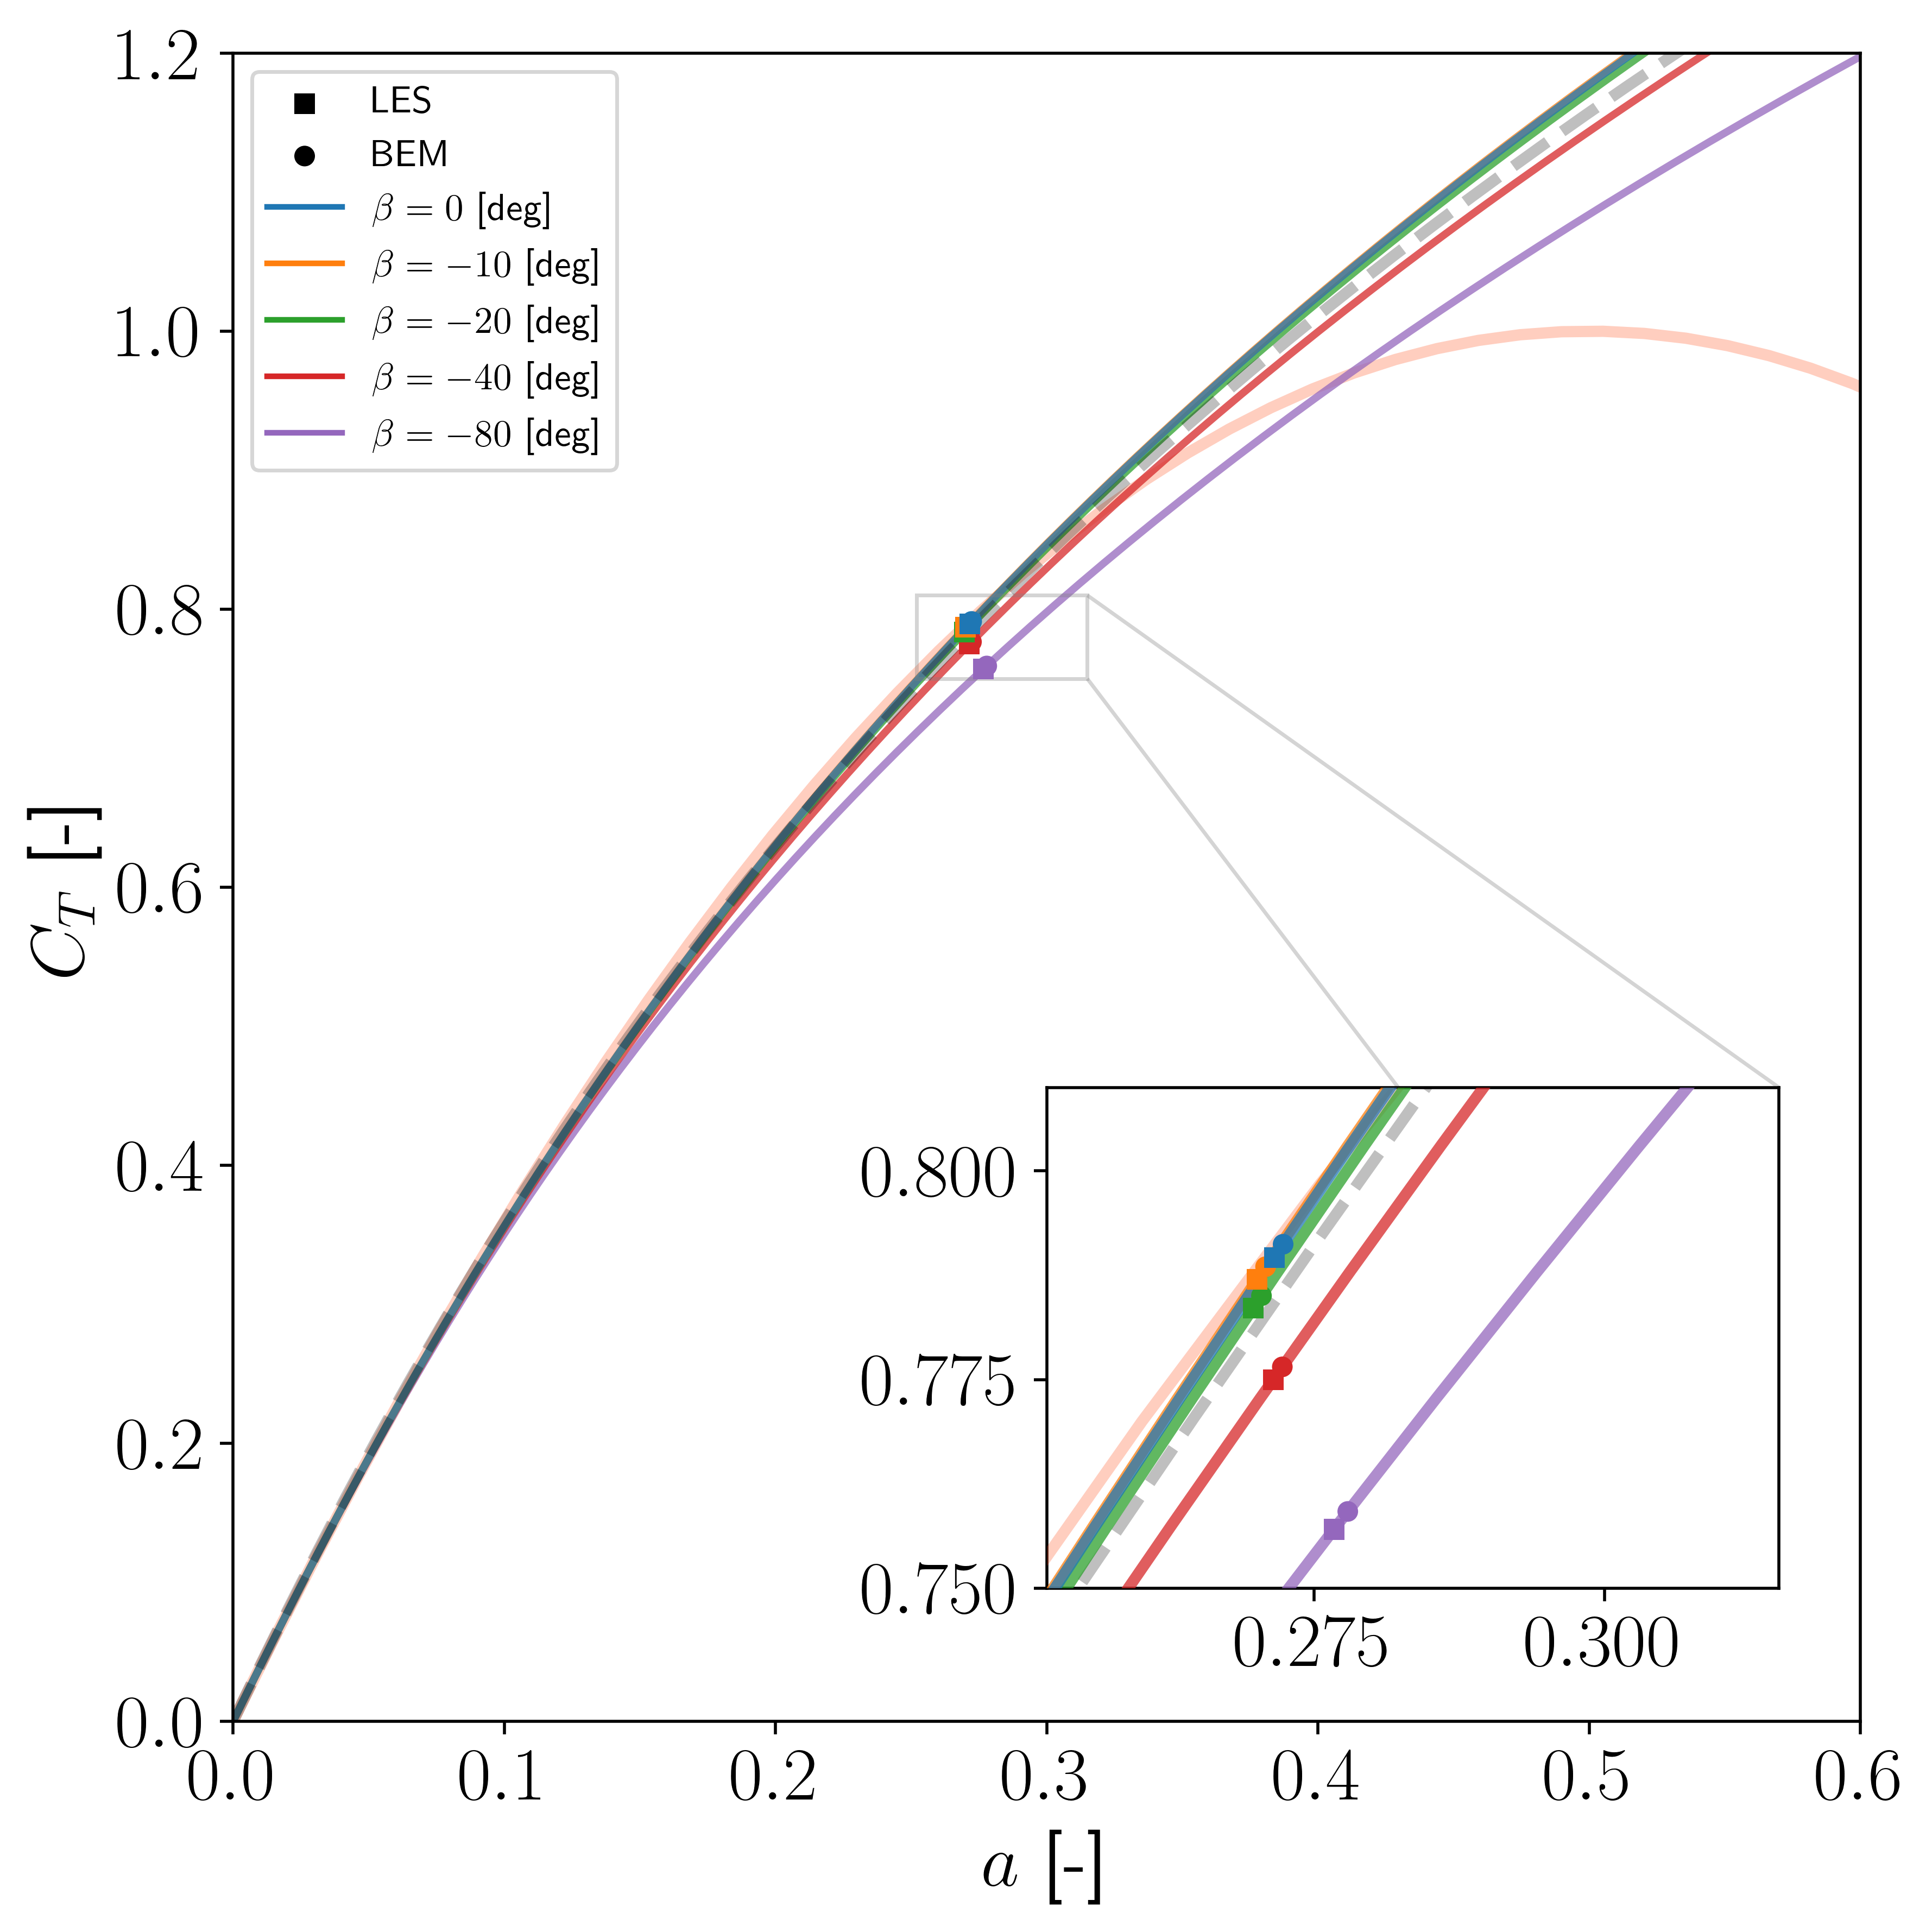

In [84]:
fig, ax = plt.subplots(figsize=(7, 7), constrained_layout=True,sharex=True, sharey=True)

colors = sns.color_palette("tab10", 5)[::-1]

allowed_values = [0,-10, -20, -40, -80]
inds = [i for i, (s, v) in enumerate(training) if (v in allowed_values and abs(s) == 0)]

a_mom  = np.linspace(0,0.75,50)
ct_mom = 4 * a_mom * (1 - a_mom)
ax.plot(a_mom, ct_mom, '#ff3c00',linewidth=3,zorder=1,alpha=0.25)

ct_mad = np.linspace(0,1.5,75)
k1 = 0.2460
k2 = 0.0586
k3 = 0.0883
a_mad = k3 * ct_mad**3 + k2 * ct_mad**2 + k1 * ct_mad
ax.plot(a_mad, ct_mad, 'k--',linewidth=3,zorder=2,alpha=0.25)

ax.scatter(-10, -10, s=30, edgecolor='none',color='k',marker='s',zorder=3,label='LES')
ax.scatter(-10, -10, s=30, edgecolor='none',color='k',zorder=3,label='BEM')

# === Add inset axes ===
# Example: Zoom into a cluster near a=0.32, CT=0.7

inset_ax = ax.inset_axes(
   [0.5, 0.08, 0.45, 0.3],  # [x, y, width, height] w.r.t. axes
    xlim=[0.252, 0.315], ylim=[0.75, 0.81] # sets viewport & tells relation to main axes
    # xticklabels=[], yticklabels=[]
)

ax.plot([-5,-5], [-5,-5], color=colors[4],zorder=4,label='$\\beta = 0$ [deg]')
ax.plot([-5,-5], [-5,-5], color=colors[3],zorder=4,label='$\\beta = -10$ [deg]')
ax.plot([-5,-5], [-5,-5], color=colors[2],zorder=4,label='$\\beta = -20$ [deg]')
ax.plot([-5,-5], [-5,-5], color=colors[1],zorder=4,label='$\\beta = -40$ [deg]')
ax.plot([-5,-5], [-5,-5], color=colors[0],zorder=4,label='$\\beta = -80$ [deg]')

ax.legend()

# # Plot the same data inside the inset
inset_ax.plot(a_mom, ct_mom, '#ff3c00', linewidth=3, alpha=0.25,zorder=3)
inset_ax.plot(a_mad, ct_mad, 'k--', linewidth=3, alpha=0.25,zorder=3)

for i in range(len(inds)):
    x_fit = np.linspace(0, 1.5, 100)
    y_fit_v00 = madsen_func(x_fit, a_coeffs[coords[inds[i]][1],coords[inds[i]][0]], b_coeffs[coords[inds[i]][1],coords[inds[i]][0]], c_coeffs[coords[inds[i]][1],coords[inds[i]][0]])
    inset_ax.plot(y_fit_v00, x_fit, color=colors[i],linewidth=3,zorder=3,alpha=0.75)
    ax.plot(y_fit_v00, x_fit, color=colors[i],linewidth=2,zorder=1,alpha=0.75)

    inset_ax.scatter(wrf_ind[inds[i]], wrf_cot[inds[i]], s=30, edgecolor='none',marker='s', color=colors[i],zorder=4)
    inset_ax.scatter(mit_ind[inds[i]], mit_cot[inds[i]], s=30, edgecolor='none',color=colors[i],zorder=4)

    ax.scatter(wrf_ind[inds[i]], wrf_cot[inds[i]], s=30, edgecolor='none',marker='s', color=colors[i],zorder=4)
    ax.scatter(mit_ind[inds[i]], mit_cot[inds[i]], s=30, edgecolor='none',color=colors[i],zorder=4)


rect = patches.Rectangle((0.2, 0.6), 0.2, 0.3, facecolor='white', edgecolor='k',zorder=2)
inset_ax.add_patch(rect)

mark_inset(ax, inset_ax, loc1=1, loc2=4, fc="none", ec="0.5",zorder=1,alpha=1/3)

ax.set_xlim([0,0.6])
ax.set_ylim([0,1.2])

ax.set_ylabel('$C_T$ [-]', fontsize=20)
ax.set_xlabel('$a$ [-]', fontsize=20)